# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of another two synthetic data generation models:
1. **CTAB GAN Plus** - Conditional Tabular GAN plus
2. **WGAN-GP** - Wassertian GAN with gradiant penalty 

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


# Generating synthetic data

In [1]:
!git clone https://github.com/Team-TUD/CTAB-GAN-Plus
import sys
sys.path.append('./CTAB-GAN-Plus')
from model.ctabgan import CTABGAN

fatal: destination path 'CTAB-GAN-Plus' already exists and is not an empty directory.


In [5]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, LabelEncoder
from model.ctabgan import CTABGAN

# -----------------------------
# Load Adult dataset
# -----------------------------
adult = fetch_ucirepo(id=2)
X = adult.data.features
y = adult.data.targets
data = pd.concat([X, y], axis=1)

target_col = y.columns[0]

# Replace ? with NaN
data = data.replace("?", np.nan)

# Take only 1000 real samples
n_samples = min(1000, len(data))
data = data.sample(n=n_samples, random_state=42).reset_index(drop=True)
X = data.drop(columns=[target_col])

# -----------------------------
# CTABGAN
# -----------------------------
data_path = "adult_data_1000.csv"
data.to_csv(data_path, index=False)

categorical_columns = data.select_dtypes(include=["object", "category"]).columns.tolist()
integer_columns = X.select_dtypes(include=["int64", "int32"]).columns.tolist()

ctabgan = CTABGAN(
    raw_csv_path=data_path,
    categorical_columns=categorical_columns,
    log_columns=[],
    mixed_columns={},
    integer_columns=integer_columns,
    problem_type={"Classification": target_col}
)

ctabgan.fit()

synthetic_ctabgan = ctabgan.data_prep.inverse_prep(
    ctabgan.synthesizer.sample(1000)
)

# -----------------------------
# WGAN-GP
# -----------------------------
data_wgan = data.copy()

# Fill missing values
for col in data_wgan.columns:
    if data_wgan[col].dtype == "object":
        data_wgan[col] = data_wgan[col].fillna("Missing")
    else:
        data_wgan[col] = data_wgan[col].fillna(data_wgan[col].median())

# Encode categorical columns
label_encoders = {}
categorical_cols_wgan = data_wgan.select_dtypes(include=["object", "category"]).columns.tolist()

for col in categorical_cols_wgan:
    le = LabelEncoder()
    data_wgan[col] = le.fit_transform(data_wgan[col].astype(str))
    label_encoders[col] = le

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_wgan)
real_columns = data_wgan.columns

device = "cuda" if torch.cuda.is_available() else "cpu"
real_tensor = torch.tensor(scaled_data, dtype=torch.float32).to(device)

batch_size = 64
latent_dim = 32
data_dim = real_tensor.shape[1]
epochs = 30
critic_iterations = 2
lambda_gp = 10

train_loader = torch.utils.data.DataLoader(
    real_tensor, batch_size=batch_size, shuffle=True, drop_last=True
)

class Generator(nn.Module):
    def __init__(self, latent_dim, data_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, data_dim),
        )

    def forward(self, z):
        return self.model(z)

class Critic(nn.Module):
    def __init__(self, data_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(data_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.model(x)

generator = Generator(latent_dim, data_dim).to(device)
critic = Critic(data_dim).to(device)

optimizer_G = optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.9))
optimizer_C = optim.Adam(critic.parameters(), lr=0.0001, betas=(0.5, 0.9))

def gradient_penalty(critic, real_samples, fake_samples):
    bs = real_samples.size(0)
    alpha = torch.rand(bs, 1, device=device).expand_as(real_samples)
    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
    critic_interpolates = critic(interpolates)
    gradients = torch.autograd.grad(
        outputs=critic_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(critic_interpolates),
        create_graph=True,
        retain_graph=True,
    )[0]
    gradients = gradients.view(bs, -1)
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

for epoch in range(epochs):
    for real_batch in train_loader:
        real_batch = real_batch.to(device)

        for _ in range(critic_iterations):
            z = torch.randn(real_batch.size(0), latent_dim, device=device)
            fake_batch = generator(z).detach()

            critic_real = critic(real_batch).mean()
            critic_fake = critic(fake_batch).mean()
            gp = gradient_penalty(critic, real_batch, fake_batch)

            critic_loss = critic_fake - critic_real + lambda_gp * gp

            optimizer_C.zero_grad()
            critic_loss.backward()
            optimizer_C.step()

        z = torch.randn(real_batch.size(0), latent_dim, device=device)
        generated_batch = generator(z)
        generator_loss = -critic(generated_batch).mean()

        optimizer_G.zero_grad()
        generator_loss.backward()
        optimizer_G.step()

generator.eval()
with torch.no_grad():
    z = torch.randn(1000, latent_dim, device=device)
    synthetic_scaled = generator(z).cpu().numpy()

synthetic_array = scaler.inverse_transform(synthetic_scaled)
synthetic_wgan = pd.DataFrame(synthetic_array, columns=real_columns)

# Round integer columns
for col in integer_columns:
    synthetic_wgan[col] = synthetic_wgan[col].round().astype(int)

# Decode categorical columns
for col, le in label_encoders.items():
    synthetic_wgan[col] = synthetic_wgan[col].round().clip(0, len(le.classes_) - 1).astype(int)
    synthetic_wgan[col] = le.inverse_transform(synthetic_wgan[col])

# -----------------------------
# Outputs in memory
# -----------------------------
real_sample = data.copy()

synthetic_outputs = {
    "Real": real_sample,
    "CTABGAN": synthetic_ctabgan,
    "WGAN_GP": synthetic_wgan
}


100%|██████████| 150/150 [26:00<00:00, 10.40s/it]  


Finished training in 1560.5801706314087  seconds.


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 617.17it/s]|
Column Shapes Score: 79.81%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 254.54it/s]|
Column Pair Trends Score: 64.89%

Overall Score (Average): 72.35%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 922.79it/s]|
Column Shapes Score: 62.34%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 351.72it/s]|
Column Pair Trends Score: 31.18%

Overall Score (Average): 46.76%



,Model,Average_Column_Shapes_Score
0,CTABGAN,0.798083
1,WGAN_GP,0.623362


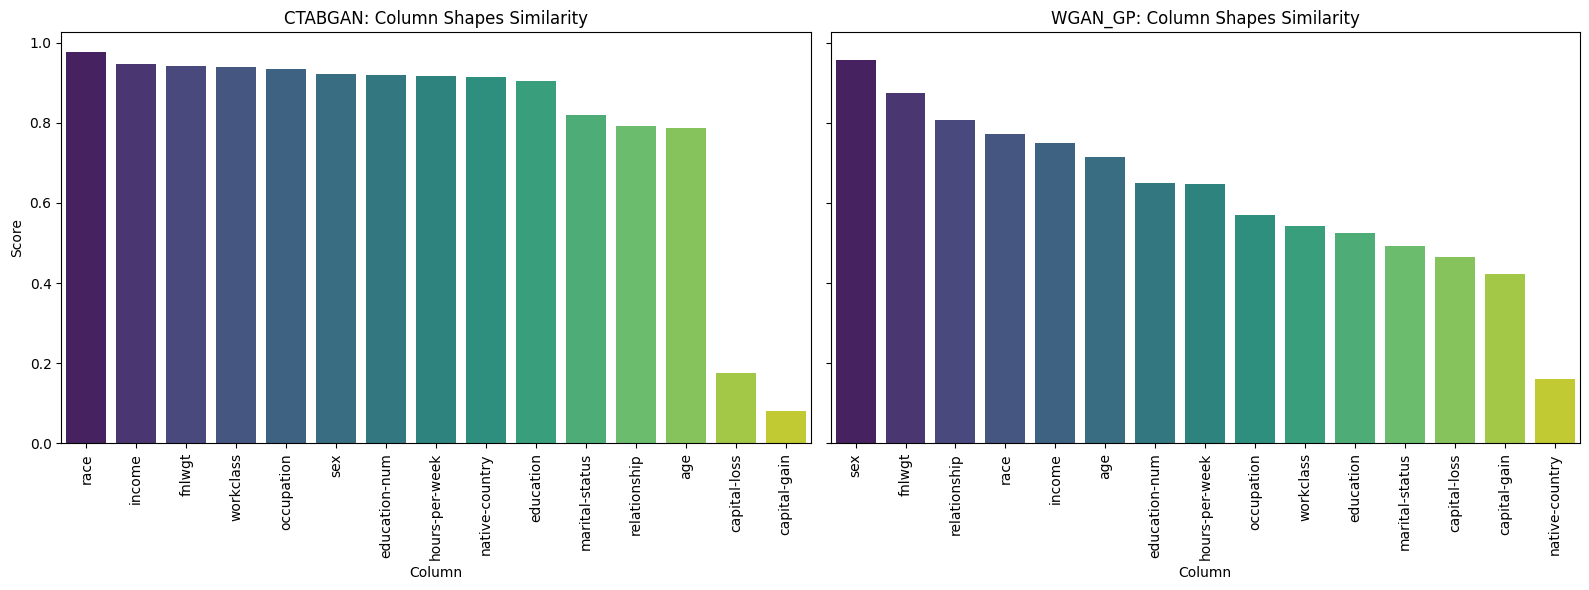

,Column,Metric,Score,Model
0,race,TVComplement,0.977000,CTABGAN
1,income,TVComplement,0.947000,CTABGAN
2,fnlwgt,KSComplement,0.941000,CTABGAN
3,workclass,TVComplement,0.940236,CTABGAN
4,occupation,TVComplement,0.933194,CTABGAN
5,sex,TVComplement,0.921000,CTABGAN
6,education-num,KSComplement,0.919000,CTABGAN
7,hours-per-week,KSComplement,0.918000,CTABGAN
8,native-country,TVComplement,0.914813,CTABGAN
9,education,TVComplement,0.905000,CTABGAN


In [6]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sdv.metadata import SingleTableMetadata

# -----------------------------
# 1. Use cleaned real data
# -----------------------------
# real_data should be the same 1000-row cleaned dataset used earlier
# For example:
# real_data = data.copy()

real_data = data.copy()

# Keep only columns that exist in both real and synthetic outputs if needed
# real_data = real_data[synthetic_outputs["CTABGAN"].columns.intersection(real_data.columns)]

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(real_data)

model_order = ["CTABGAN", "WGAN_GP"]
column_shape_details = {}
summary_rows = []

for model_name in model_order:
    qr = QualityReport()
    synthetic_data = synthetic_outputs[model_name]

    # Align columns to avoid mismatch errors
    common_cols = real_data.columns.intersection(synthetic_data.columns)
    real_eval = real_data[common_cols].copy()
    synth_eval = synthetic_data[common_cols].copy()

    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=metadata.to_dict()
    )

    details = qr.get_details("Column Shapes")

    # Handle either "Score" or "Quality Score" depending on SDV version
    score_col = "Score" if "Score" in details.columns else "Quality Score"
    details = details.sort_values(score_col, ascending=False)
    column_shape_details[model_name] = details

    summary_rows.append({
        "Model": model_name,
        "Average_Column_Shapes_Score": float(details[score_col].mean())
    })

# -----------------------------
# 2. Summary table
# -----------------------------
summary_df = pd.DataFrame(summary_rows).sort_values(
    "Average_Column_Shapes_Score", ascending=False
)
display(summary_df)

# -----------------------------
# 3. Plot column-shape scores
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    score_col = "Score" if "Score" in details.columns else "Quality Score"

    sns.barplot(
        x="Column",
        y=score_col,
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

# -----------------------------
# 4. Combined details table
# -----------------------------
combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))

### 1.2. Jensen–Shannon divergence

In [7]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")

Computing JS divergence for CTABGAN...
Computing JS divergence for WGAN_GP...


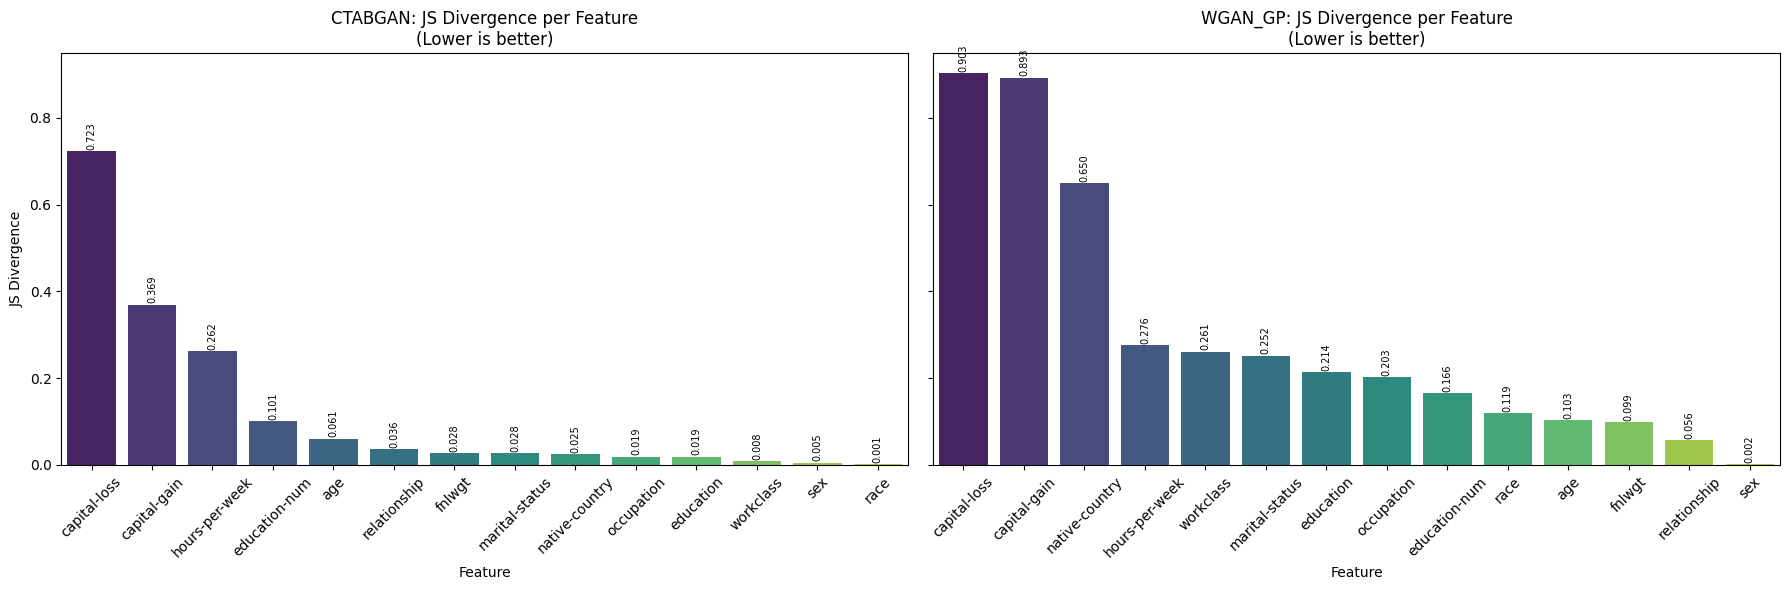

Top 20 features by JS Divergence:


,Feature,JS_Divergence,Model
0,capital-loss,0.723181,CTABGAN
1,capital-gain,0.369169,CTABGAN
2,hours-per-week,0.262052,CTABGAN
3,education-num,0.100877,CTABGAN
4,age,0.060669,CTABGAN
5,relationship,0.036197,CTABGAN
6,fnlwgt,0.027625,CTABGAN
7,marital-status,0.027578,CTABGAN
8,native-country,0.024645,CTABGAN
9,occupation,0.018918,CTABGAN



Model Comparison Summary (Lower JS = Better):


,Model,Mean_JS,Median_JS,Max_JS,Features_with_JS_gt_0.1
0,CTABGAN,0.120311,0.027601,0.723181,4
1,WGAN_GP,0.299840,0.208363,0.903478,11


In [8]:
# Use the real_sample from previous cell (1000 rows)
real_df = real_sample.drop(columns=[target_col])  

model_order = ["CTABGAN", "WGAN_GP"]
js_results_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col])
    
    print(f"Computing JS divergence for {model_name}...")
    js_df = compute_js_divergence(
        real_df,
        synth_df,
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    
    js_results_by_model[model_name] = js_df

# -----------------------------
# Plot JS Divergence
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df.head(15),  # Top 15 features for cleaner plot
        palette="viridis",
        ax=ax
    )

    # Add value labels on bars
    for bar in bars.patches:
        yval = bar.get_height()
        if not np.isnan(yval):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                yval + 0.003,
                f"{yval:.3f}",
                ha="center",
                va="bottom",
                fontsize=7,
                rotation=90
            )

    ax.set_title(f"{model_name}: JS Divergence per Feature\n(Lower is better)", fontsize=12)
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# -----------------------------
# Summary table
# -----------------------------
all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)

print("Top 20 features by JS Divergence:")
display(all_js.head(20))

# -----------------------------
# Model comparison summary
# -----------------------------
summary_stats = []
for model_name, js_df in js_results_by_model.items():
    valid_js = js_df["JS_Divergence"].dropna()
    summary_stats.append({
        "Model": model_name,
        "Mean_JS": valid_js.mean(),
        "Median_JS": valid_js.median(),
        "Max_JS": valid_js.max(),
        "Features_with_JS_gt_0.1": (valid_js > 0.1).sum()
    })

summary_df = pd.DataFrame(summary_stats).sort_values("Mean_JS")
print("\nModel Comparison Summary (Lower JS = Better):")
display(summary_df)

### 1.3 Wasserstein Distance


Numeric columns (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss']...
Categorical columns (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship']...

Using 6 numeric features for Wasserstein distance

Computing Wasserstein distances...

CTABGAN - Wasserstein Distance (numeric features only):
  age            : 0.0792
  fnlwgt         : 0.0142
  education-num  : 0.0275
  capital-gain   : 0.0434
  capital-loss   : 0.0735
  hours-per-week : 0.0199
WGAN_GP - Wasserstein Distance (numeric features only):
  age            : 0.1335
  fnlwgt         : 0.0543
  education-num  : 0.0994
  capital-gain   : 0.0304
  capital-loss   : 0.0859
  hours-per-week : 0.0466

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein,Num_Valid_Features
0,CTABGAN,0.042970,0.035464,0.079233,6
1,WGAN_GP,0.075009,0.070090,0.133507,6


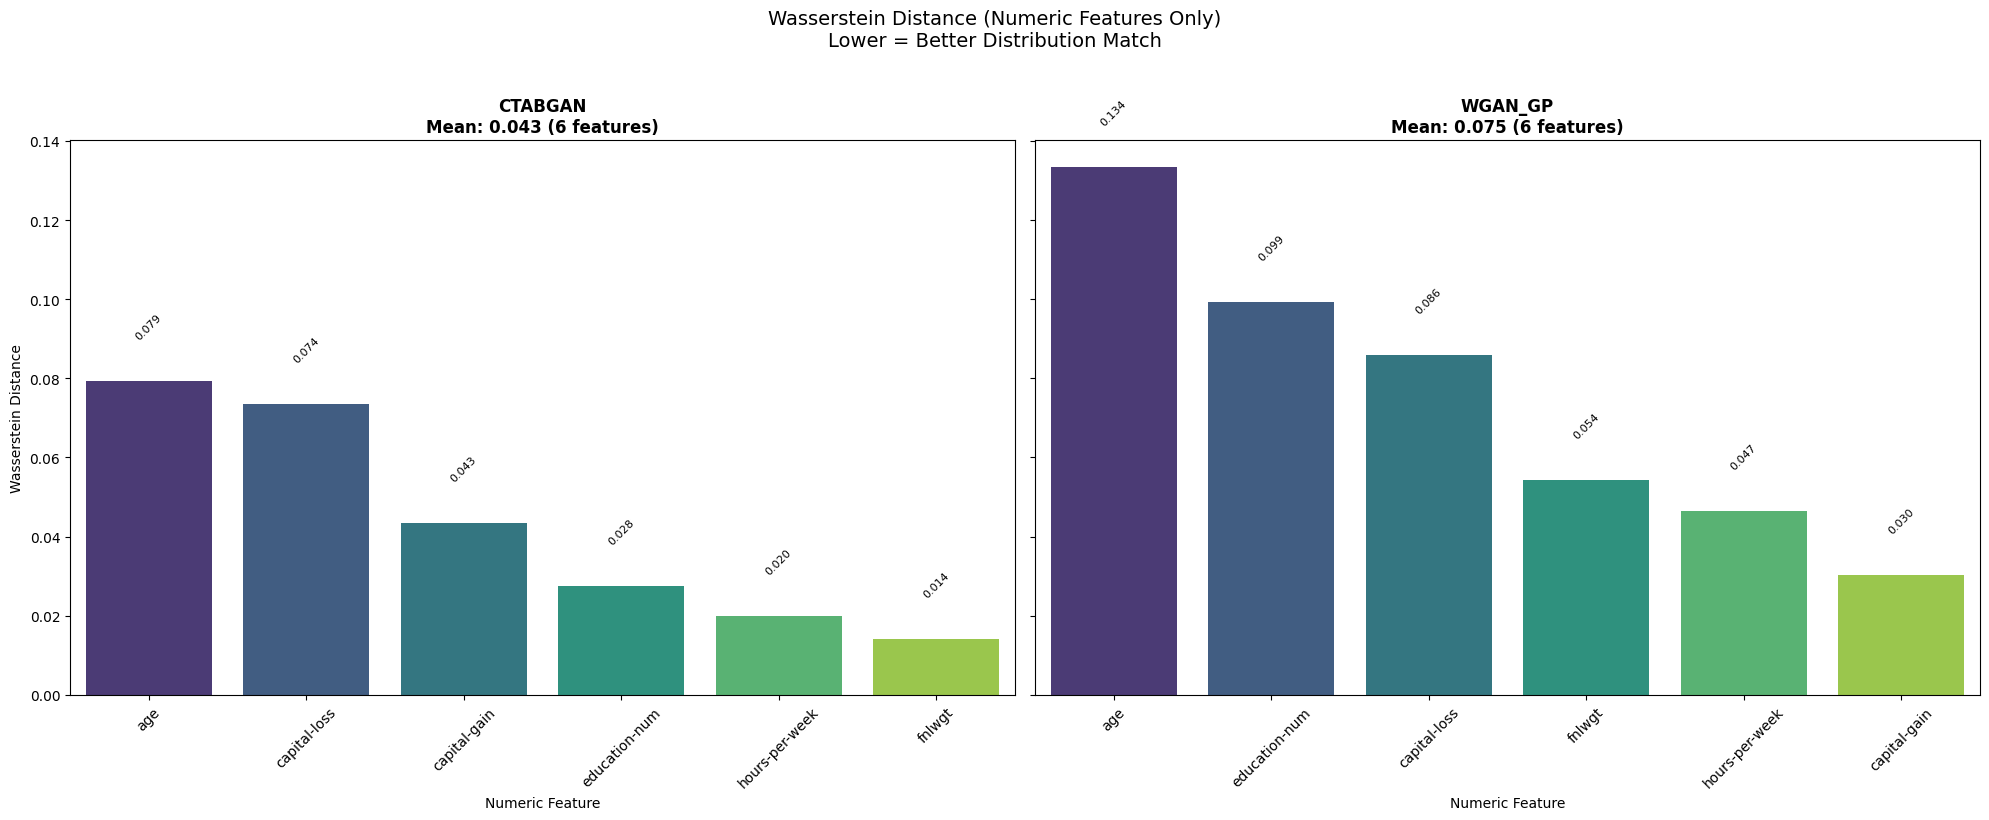


Top 20 numeric features by Wasserstein Distance:


,Feature,Wasserstein_Distance,Model
6,age,0.133507,WGAN_GP
7,education-num,0.099400,WGAN_GP
8,capital-loss,0.085887,WGAN_GP
0,age,0.079233,CTABGAN
1,capital-loss,0.073546,CTABGAN
9,fnlwgt,0.054292,WGAN_GP
10,hours-per-week,0.046582,WGAN_GP
2,capital-gain,0.043395,CTABGAN
11,capital-gain,0.030388,WGAN_GP
3,education-num,0.027533,CTABGAN


In [11]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTABGAN", "WGAN_GP"]

# Use real_sample and target_col from previous generation cell
real_df = real_sample.drop(columns=[target_col])

# -----------------------------
# SEPARATE NUMERIC AND CATEGORICAL COLUMNS
# -----------------------------
numeric_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = real_df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols[:5]}...")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols[:5]}...")

# Only use NUMERIC columns for Wasserstein (skip categorical)
real_numeric = real_df[numeric_cols].copy()
print(f"\nUsing {len(numeric_cols)} numeric features for Wasserstein distance")

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_numeric),
    columns=numeric_cols,
    index=real_numeric.index
)

wasserstein_by_model = {}
summary_rows = []

print("\nComputing Wasserstein distances...\n")

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col])
    synth_numeric = synth_df[numeric_cols].copy()
    
    # Clean numeric data (handle inf/NaN)
    synth_numeric = synth_numeric.replace([np.inf, -np.inf], np.nan)
    synth_numeric = synth_numeric.fillna(synth_numeric.median())
    
    # Scale synthetic data using real data's scaler
    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_numeric),
        columns=numeric_cols,
        index=synth_numeric.index
    )
    
    dists = []
    print(f"{model_name} - Wasserstein Distance (numeric features only):")
    
    for col in numeric_cols:
        try:
            real_col = real_scaled[col].dropna()
            synth_col = synthetic_scaled[col].dropna()
            
            if len(real_col) > 1 and len(synth_col) > 1:
                dist = wasserstein_distance(real_col, synth_col)
                dists.append((col, float(dist)))
                print(f"  {col:15}: {dist:.4f}")
            else:
                dists.append((col, np.nan))
                print(f"  {col:15}: NaN (insufficient data)")
        except Exception as e:
            dists.append((col, np.nan))
            print(f"  {col:15}: NaN (error: {str(e)[:30]})")
    
    # FIXED: Remove na_last parameter for older pandas
    dist_df = pd.DataFrame(
        dists,
        columns=["Feature", "Wasserstein_Distance"]
    ).sort_values("Wasserstein_Distance", ascending=False)
    
    wasserstein_by_model[model_name] = dist_df
    
    valid_dists = dist_df["Wasserstein_Distance"].dropna()
    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": valid_dists.mean() if len(valid_dists) > 0 else np.nan,
        "Median_Wasserstein": valid_dists.median() if len(valid_dists) > 0 else np.nan,
        "Max_Wasserstein": valid_dists.max() if len(valid_dists) > 0 else np.nan,
        "Num_Valid_Features": len(valid_dists)
    })

# FIXED: Remove na_last parameter
summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

# Plot TOP 15 numeric features only
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name].dropna().head(15)
    
    if len(df_plot) > 0:
        bars = sns.barplot(
            x="Feature",
            y="Wasserstein_Distance",
            data=df_plot,
            palette="viridis",
            ax=ax
        )
        
        # Add value labels
        for bar in bars.patches:
            yval = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                yval + 0.01,
                f"{yval:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=45
            )
        
        mean_ws = summary_df[summary_df['Model']==model_name]['Mean_Wasserstein'].iloc[0]
        ax.set_title(f"{model_name}\nMean: {mean_ws:.3f} ({len(df_plot)} features)", 
                    fontsize=12, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'No numeric data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(model_name)
    
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Numeric Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.suptitle("Wasserstein Distance (Numeric Features Only)\nLower = Better Distribution Match", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# FIXED: Remove na_last parameter
all_wasserstein = pd.concat(
    [df.assign(Model=name) for name, df in wasserstein_by_model.items()],
    ignore_index=True
).sort_values("Wasserstein_Distance", ascending=False)

print("\nTop 20 numeric features by Wasserstein Distance:")
display(all_wasserstein.head(20))

### 1.4 Gower Distance

In [12]:
import numpy as np
import pandas as pd
import gower

# Use correct variables from Adult dataset pipeline
data = real_sample.copy()
model_order = ["CTABGAN", "WGAN_GP"]
target_col = data.columns[-1]  # Use last column as target (income)

X_real = data.drop(columns=[target_col], errors="ignore")

gower_results = []

print("Computing Gower distances (mixed data)...\n")

for model_name in model_order:
    X_synth = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    
    # Align columns exactly
    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True)
    Xs = X_synth[common_cols].reset_index(drop=True)
    
    print(f"{model_name}: {len(Xr)} real vs {len(Xs)} synth samples, {len(common_cols)} features")
    
    # Gower similarity matrices (1 - distance)
    try:
        gower_real = 1 - gower.gower_matrix(Xr)
        gower_synth = 1 - gower.gower_matrix(Xs)
        
        # Upper triangle (excluding diagonal)
        real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
        synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]
        
        max_intra_real = np.max(real_upper)
        avg_intra_real = np.mean(real_upper)
        max_intra_synth = np.max(synth_upper)
        avg_intra_synth = np.mean(synth_upper)
        
        # Cross similarity (real vs synthetic)
        combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
        gower_combined = 1 - gower.gower_matrix(combined)
        n_real = len(Xr)
        cross_block = gower_combined[:n_real, n_real:]
        
        max_cross = np.max(cross_block)
        avg_cross = np.mean(cross_block)
        
        print(f"\n{model_name} - Gower Similarity:")
        print("Intra-set Similarity (Real):")
        print(f"  Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}")
        print("Intra-set Similarity (Synthetic):")
        print(f"  Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}")
        print("Cross-set Similarity (Real vs Synthetic):")
        print(f"  Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")
        
        gower_results.append({
            "Model": model_name,
            "Max_Intra_Real": max_intra_real,
            "Avg_Intra_Real": avg_intra_real,
            "Max_Intra_Synth": max_intra_synth,
            "Avg_Intra_Synth": avg_intra_synth,
            "Max_Cross_Real_vs_Synth": max_cross,
            "Avg_Cross_Real_vs_Synth": avg_cross,
        })
        
    except Exception as e:
        print(f"Error computing Gower for {model_name}: {str(e)}")
        continue

# Summary table
if gower_results:
    gower_summary_df = pd.DataFrame(gower_results)
    print("\nGower Similarity Summary:")
    print("(Higher similarity = better; ideal: synth intra ≈ real intra ≈ cross)")
    display(gower_summary_df)
    
    # Add interpretation
    for _, row in gower_summary_df.iterrows():
        model = row['Model']
        real_avg = row['Avg_Intra_Real']
        synth_avg = row['Avg_Intra_Synth']
        cross_avg = row['Avg_Cross_Real_vs_Synth']
        
        print(f"\n{model} interpretation:")
        if abs(synth_avg - real_avg) < 0.05 and abs(cross_avg - real_avg) < 0.05:
            print(" Good: Synthetic matches real data distribution")
        elif synth_avg > real_avg * 1.1:
            print("  Synthetic data is less diverse than real")
        elif cross_avg < real_avg * 0.8:
            print("  Poor: Synthetic doesn't resemble real data")
        else:
            print(" Moderate quality")
else:
    print("No valid Gower results computed")

Computing Gower distances (mixed data)...

CTABGAN: 1000 real vs 1000 synth samples, 14 features

CTABGAN - Gower Similarity:
Intra-set Similarity (Real):
  Max = 0.9992, Avg = 0.6225
Intra-set Similarity (Synthetic):
  Max = 0.9935, Avg = 0.5656
Cross-set Similarity (Real vs Synthetic):
  Max = 0.9932, Avg = 0.6121
WGAN_GP: 1000 real vs 1000 synth samples, 14 features

WGAN_GP - Gower Similarity:
Intra-set Similarity (Real):
  Max = 0.9992, Avg = 0.6225
Intra-set Similarity (Synthetic):
  Max = 0.9837, Avg = 0.5071
Cross-set Similarity (Real vs Synthetic):
  Max = 0.9637, Avg = 0.5211

Gower Similarity Summary:
(Higher similarity = better; ideal: synth intra ≈ real intra ≈ cross)


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTABGAN,0.999184,0.622501,0.993459,0.565613,0.993195,0.612060
1,WGAN_GP,0.999184,0.622501,0.983747,0.507128,0.963664,0.521082



CTABGAN interpretation:
 Moderate quality

WGAN_GP interpretation:
 Moderate quality


### 1.5 t-SNE Visualization


Using 6 numeric features for t-SNE: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


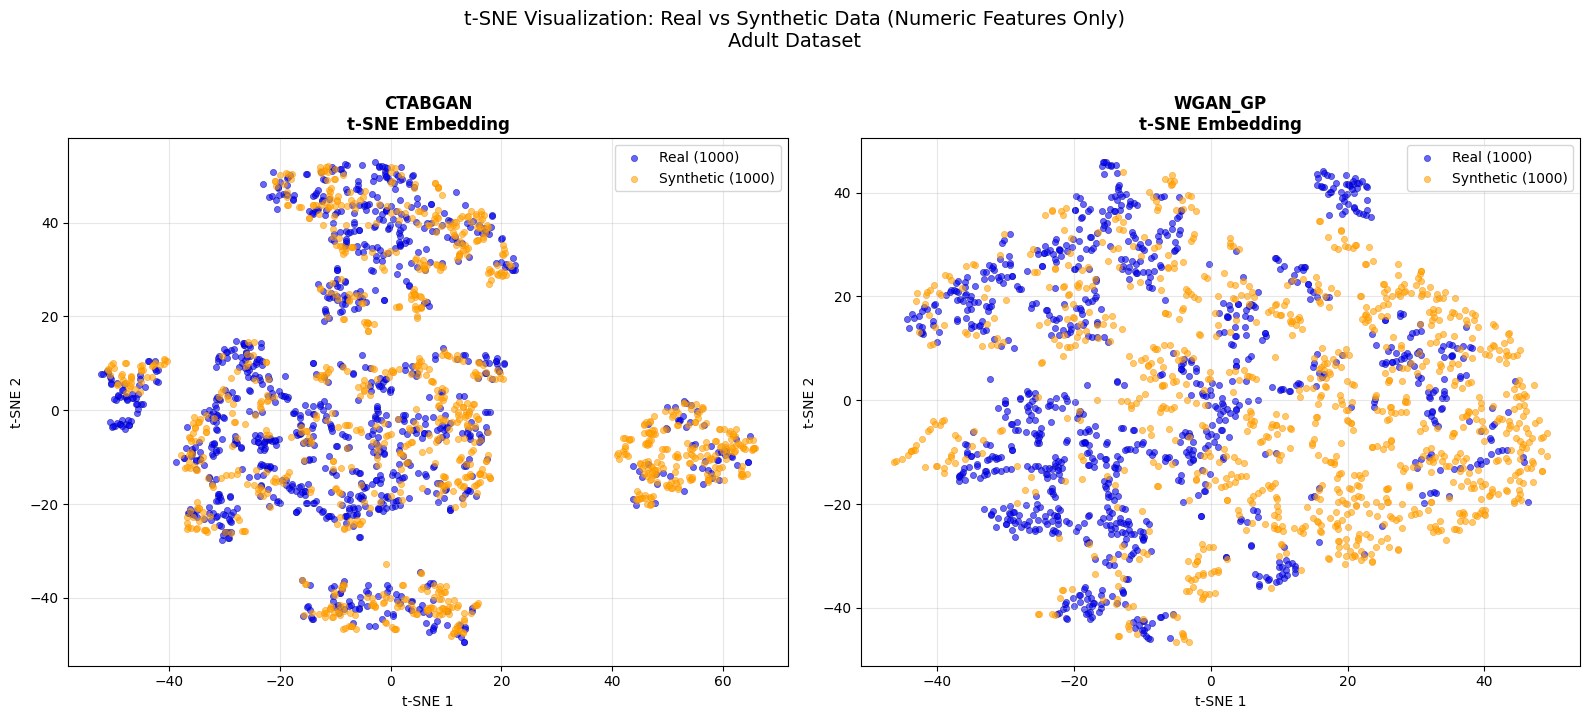


Overlap Analysis:
CTABGAN: Centroid distance = 18.272
Limited overlap
WGAN_GP: Centroid distance = 18.272
Limited overlap


In [13]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use correct Adult dataset variables
model_order = ["CTABGAN", "WGAN_GP"]
data = real_sample.copy()
target_col = data.columns[-1]  # income target column

# Remove target and separate numeric/categorical
X_real = data.drop(columns=[target_col], errors="ignore")

# -----------------------------
# USE ONLY NUMERIC COLUMNS (like before)
# -----------------------------
numeric_cols = X_real.select_dtypes(include=[np.number]).columns.tolist()
print(f"Using {len(numeric_cols)} numeric features for t-SNE: {numeric_cols}")

X_real_numeric = X_real[numeric_cols].copy()

# Scale numeric data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(X_real_numeric),
    columns=numeric_cols,
    index=X_real_numeric.index
)

# Create t-SNE plots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes = axes.flatten()

for i, model_name in enumerate(model_order):
    ax = axes[i]
    
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    synth_numeric = synth_df[numeric_cols].copy()
    
    # Clean synthetic numeric data
    synth_numeric = synth_numeric.replace([np.inf, -np.inf], np.nan)
    synth_numeric = synth_numeric.fillna(synth_numeric.median())
    
    # Scale synthetic data using real scaler
    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_numeric),
        columns=numeric_cols,
        index=synth_numeric.index
    )
    
    # Combine real + synthetic
    combined = np.vstack([
        real_scaled.values, 
        synthetic_scaled.values
    ])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))
    
    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_result = tsne.fit_transform(combined)
    
    # Plot
    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=20, label="Real (1000)", 
        edgecolors='darkblue', linewidth=0.5
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=20, label="Synthetic (1000)",
        edgecolors='darkorange', linewidth=0.5
    )
    
    ax.set_title(f"{model_name}\nt-SNE Embedding", fontsize=12, fontweight='bold')
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("t-SNE Visualization: Real vs Synthetic Data (Numeric Features Only)\nAdult Dataset", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print overlap statistics
print("\nOverlap Analysis:")
for model_name in model_order:
    # Simple convex hull overlap check (optional advanced metric)
    real_points = tsne_result[labels == "Real"][:1000]  # First 1000 real points
    synth_points = tsne_result[labels == "Synthetic"][:1000]  # First 1000 synth points
    
    # Distance between centroids
    real_center = np.mean(real_points, axis=0)
    synth_center = np.mean(synth_points, axis=0)
    centroid_dist = np.linalg.norm(real_center - synth_center)
    
    print(f"{model_name}: Centroid distance = {centroid_dist:.3f}")
    if centroid_dist < 5:
        print("Good overlap")
    else:
        print("Limited overlap")

### 1.6 MMD (Maximum Mean Discrepancy)


In [14]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

def gaussian_kernel(x, y, sigma=1.0):
    x_size = x.shape[0]
    y_size = y.shape[0]
    dim = x.shape[1]
    x_tile = np.tile(x, (y_size, 1))
    y_tile = np.repeat(y, x_size, axis=0)
    return np.exp(-np.sum((x_tile - y_tile) ** 2, axis=1) / (2 * dim * sigma ** 2)).reshape(y_size, x_size)

def compute_mmd(x, y, sigma=1.0):
    k_xx = np.mean(gaussian_kernel(x, x, sigma))
    k_yy = np.mean(gaussian_kernel(y, y, sigma))
    k_xy = np.mean(gaussian_kernel(x, y, sigma))
    return k_xx + k_yy - 2 * k_xy

model_order = ["CTABGAN", "WGAN_GP"]
data = real_sample.copy()
target_col = data.columns[-1]

# Real features (exclude target) - NUMERIC COLUMNS ONLY
real_features = data.drop(columns=[target_col], errors="ignore")
numeric_cols = real_features.select_dtypes(include=[np.number]).columns.tolist()
X_real = real_features[numeric_cols].copy()

mmd_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    X_synth = synth_df[numeric_cols].copy()
    
    # Clean synthetic data
    X_synth = X_synth.replace([np.inf, -np.inf], np.nan)
    X_synth = X_synth.fillna(X_synth.median())
    
    # Standardize using real-data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)
    
    mmd_score = compute_mmd(X_real_scaled, X_synth_scaled, sigma=1.0)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})
    
    print(f"{model_name} - MMD score: {mmd_score:.4f}")

# Lower MMD is better
mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTABGAN - MMD score: 0.1003
WGAN_GP - MMD score: 0.0817

MMD comparison (lower is better):


,Model,MMD_Score
0,WGAN_GP,0.081653
1,CTABGAN,0.100346


### 1.7 Cosine Similarity


In [15]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTABGAN", "WGAN_GP"]
data = real_sample.copy()
target_col = data.columns[-1]

# Real features (exclude target) - NUMERIC COLUMNS ONLY
real_features = data.drop(columns=[target_col], errors="ignore")
numeric_cols = real_features.select_dtypes(include=[np.number]).columns.tolist()
X_real = real_features[numeric_cols].copy()

similarity_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    X_synth = synth_df[numeric_cols].copy()
    
    # Clean synthetic data
    X_synth = X_synth.replace([np.inf, -np.inf], np.nan)
    X_synth = X_synth.fillna(X_synth.median())
    
    # Scale using real data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)
    
    # Pairwise cross similarity: all real vs all synthetic rows
    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = np.mean(cross_sim)
    max_sim = np.max(cross_sim)
    
    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")
    
    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTABGAN - Sample-Level Similarity:
Average cosine similarity: -0.0315
Maximum cosine similarity: 1.0000

WGAN_GP - Sample-Level Similarity:
Average cosine similarity: 0.0001
Maximum cosine similarity: 0.9965

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,WGAN_GP,0.000121,0.996506
1,CTABGAN,-0.031479,0.999993


### 1.8 Nearest Neighbours 


In [16]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTABGAN", "WGAN_GP"]
data = real_sample.copy()
target_col = data.columns[-1]

real_features = data.drop(columns=[target_col], errors="ignore")
numeric_cols = real_features.select_dtypes(include=[np.number]).columns.tolist()
X_real = real_features[numeric_cols].copy()

privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    X_synth = synth_df[numeric_cols].copy()
    
    # Clean synthetic data
    X_synth = X_synth.replace([np.inf, -np.inf], np.nan)
    X_synth = X_synth.fillna(X_synth.median())
    
    # Scale using real data statistics
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)
    
    # Nearest-neighbor privacy check: Synthetic -> Real
    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)
    
    avg_nn_dist = np.mean(distances)
    min_nn_dist = np.min(distances)
    p5_nn_dist = np.percentile(distances, 5)
    
    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")
    
    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTABGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.0796
Minimum NN Distance (Synthetic -> Real): 0.0103
5th Percentile NN Distance: 0.1749

WGAN_GP - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.4496
Minimum NN Distance (Synthetic -> Real): 0.2809
5th Percentile NN Distance: 0.5987

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,WGAN_GP,1.449594,0.280893,0.598683
1,CTABGAN,1.079566,0.010292,0.174893


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTABGAN,142.051511,9.678911,16.021075
1,WGAN_GP,49.179406,14.833392,17.185482


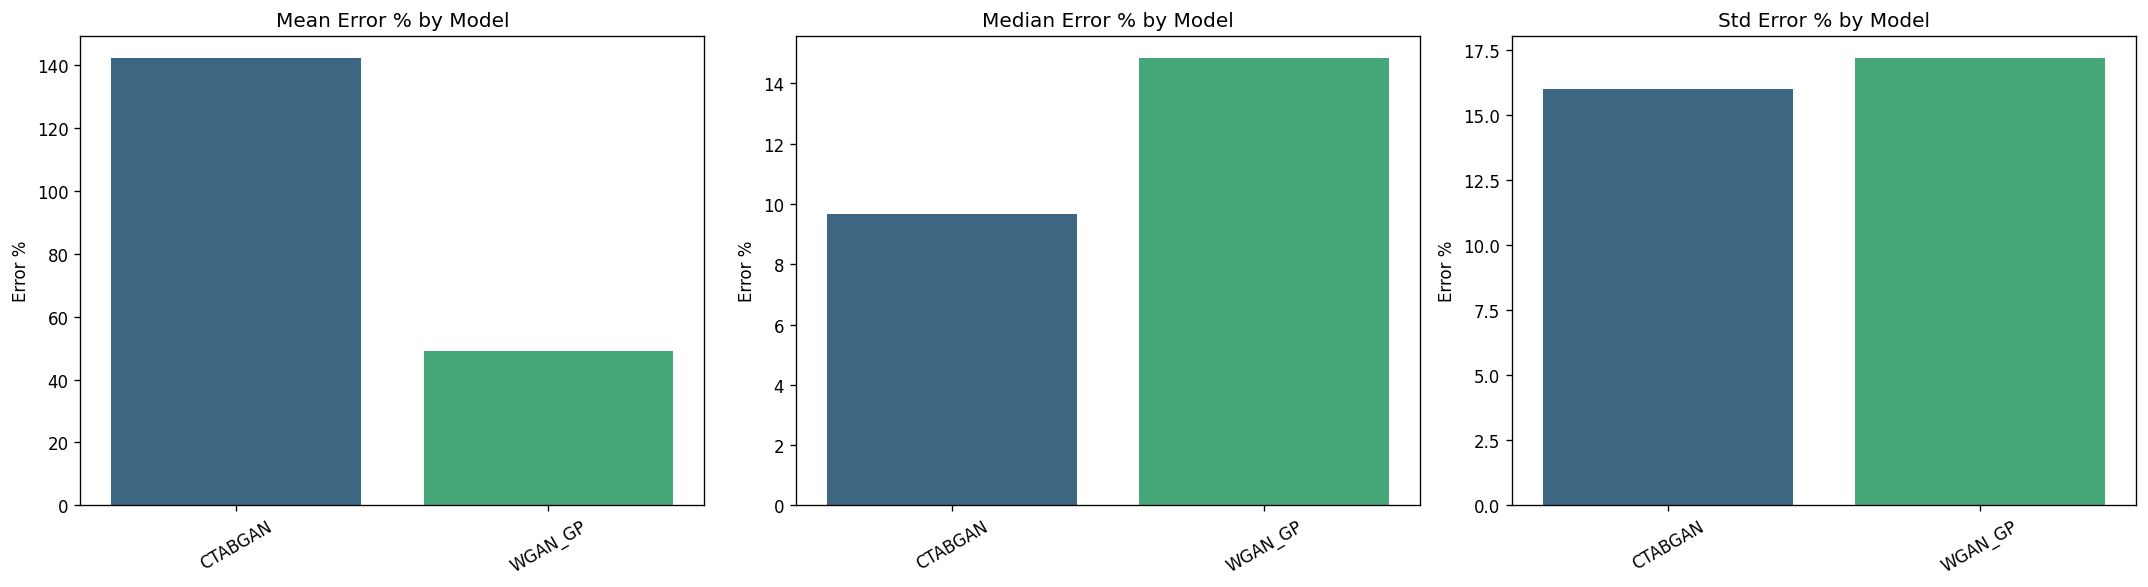

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTABGAN", "WGAN_GP"]
data = real_sample.copy()
target_col = data.columns[-1]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    synth_num_cols = synth_df.select_dtypes(include=[np.number]).columns.tolist()
    synth_df = synth_df[num_cols].copy()
    
    # Fill NaN values for numeric computation
    synth_df = synth_df.fillna(synth_df.median())
    
    real_means = real_df[num_cols].mean()
    synth_means = synth_df[num_cols].mean()
    
    real_stds = real_df[num_cols].std(ddof=1)
    synth_stds = synth_df[num_cols].std(ddof=1)
    
    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100
    
    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)
    
    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }
    
    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()

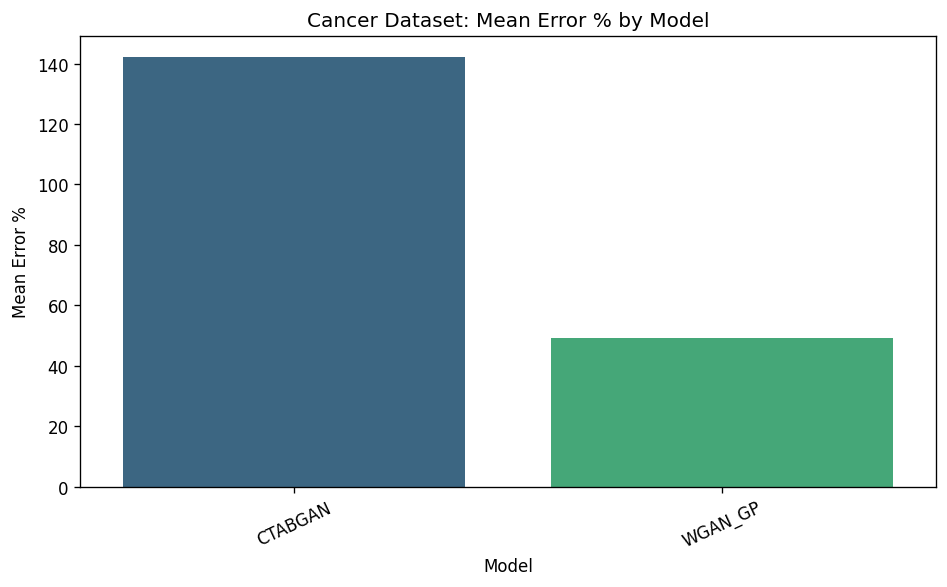

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("Cancer Dataset: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

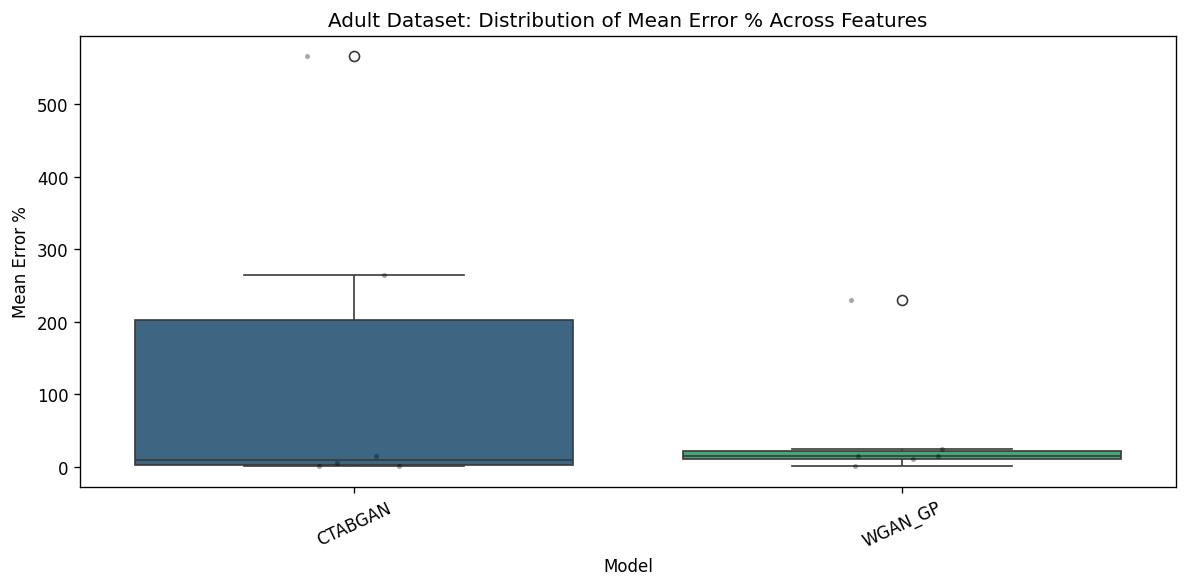

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_list = ["CTABGAN", "WGAN_GP"]

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in model_list
        if m in feature_error_by_model
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Adult Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

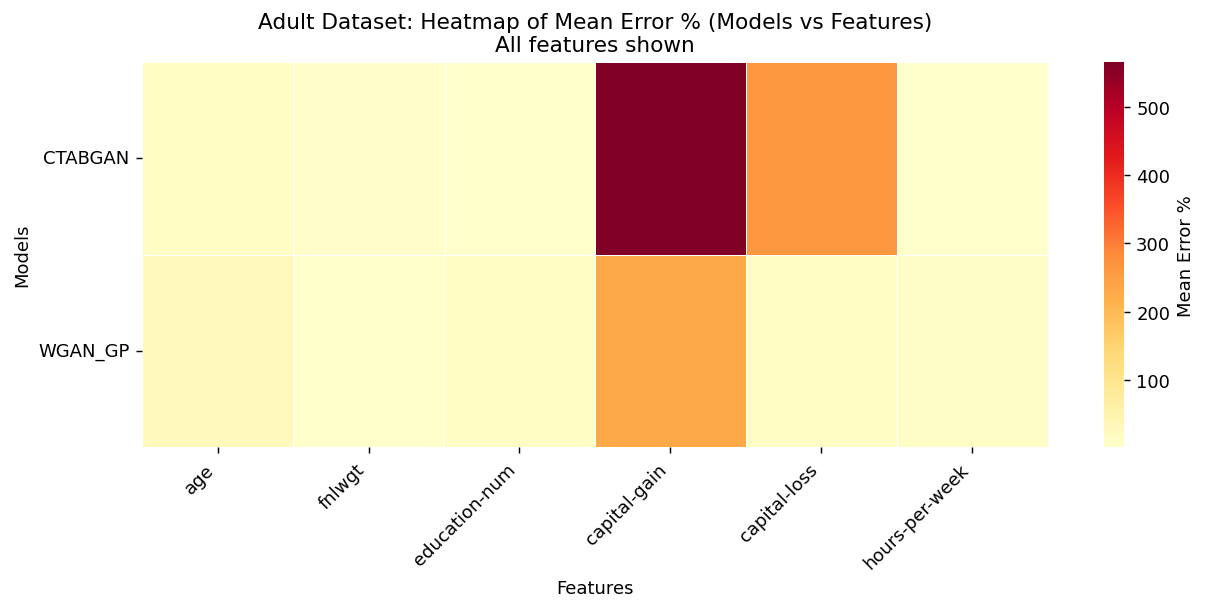

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTABGAN", "WGAN_GP"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
    if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Adult Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis


In [31]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

def bivariate_quality(real_df, synth_df, target=None):
    """Compute bivariate quality metrics for Adult dataset."""

    if target is None:
        for cand in ["income", "Income", "class", "Class", "target", "Target"]:
            if cand in real_df.columns:
                target = cand
                break

    if target is None or target not in real_df.columns or target not in synth_df.columns:
        raise KeyError("Target column not found in both real_df and synth_df.")

    num_cols = [
        c for c in real_df.columns
        if c != target and pd.api.types.is_numeric_dtype(real_df[c]) and pd.api.types.is_numeric_dtype(synth_df[c])
    ]

    scaler = MinMaxScaler()
    real_scaled = real_df[num_cols].copy()
    synth_scaled = synth_df[num_cols].copy()
    
    # Handle NaN values
    real_scaled = real_scaled.fillna(real_scaled.median())
    synth_scaled = synth_scaled.fillna(synth_scaled.median())

    real_scaled = pd.DataFrame(scaler.fit_transform(real_scaled), columns=num_cols, index=real_scaled.index)
    synth_scaled = pd.DataFrame(scaler.transform(synth_scaled), columns=num_cols, index=synth_scaled.index)

    results_corr = []
    results_target = []

    # Pairwise correlations
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    # Target-conditional distributions
    for col in num_cols:
        try:
            r_groups = [g for _, g in real_df.groupby(target) if len(g) > 0]
            s_groups = [g[col].values for _, g in synth_df.groupby(target) if len(g) > 0]
            
            if len(r_groups) >= 2 and len(s_groups) >= 2:
                # Use first two groups if more than 2
                r_group1 = r_groups[0][col].values
                r_group2 = r_groups[1][col].values
                s_group1 = s_groups[0]
                s_group2 = s_groups[1]
                
                d_real = stats.wasserstein_distance(r_group1, r_group2)
                d_synth = stats.wasserstein_distance(s_group1, s_group2)
                results_target.append({
                    "feature": col,
                    "delta_wasserstein": abs(d_real - d_synth)
                })
        except:
            continue

    corr_df = pd.DataFrame(results_corr)
    if not corr_df.empty:
        corr_df = corr_df.sort_values("delta_corr", ascending=False)
    else:
        corr_df = pd.DataFrame(columns=["var_a", "var_b", "delta_corr"])

    target_df = pd.DataFrame(results_target)
    if not target_df.empty:
        target_df = target_df.sort_values("delta_wasserstein", ascending=False)
    else:
        target_df = pd.DataFrame(columns=["feature", "delta_wasserstein"])

    return corr_df, target_df

In [32]:
import pandas as pd
import numpy as np

model_order = ["CTABGAN", "WGAN_GP"]
data = real_sample.copy()
target_col = data.columns[-1]  # Absolute target column from previous cells

real_df = data.copy()

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    # keep target column if it exists, but align numeric features separately inside the function
    if target_col not in synth_df.columns:
        print(f"Warning: {target_col} not found in synthetic data for {model_name}")
        continue

    corr_df, target_df = bivariate_quality(
        real_df=real_df,
        synth_df=synth_df,
        target=target_col
    )

    all_corr_results[model_name] = corr_df
    all_target_results[model_name] = target_df

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_df.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by target class:")
    display(target_df.head(10) if not target_df.empty else pd.DataFrame({"message": ["No target-conditional features found"]}))
    print("=" * 60)

    # Safe metric extraction with empty DataFrame handling
    corr_metric_col = next((c for c in ["delta_corr", "AbsDiff", "abs_diff", "Difference", "diff"] if c in corr_df.columns), None)
    target_metric_col = next((c for c in ["delta_wasserstein", "AbsDiff", "abs_diff", "Difference", "diff"] if c in target_df.columns), None)

    top_corr_diff = corr_df[corr_metric_col].iloc[0] if corr_metric_col and not corr_df.empty else None
    mean_top10_corr_diff = corr_df[corr_metric_col].head(10).mean() if corr_metric_col and not corr_df.empty else None
    
    top_target_diff = target_df[target_metric_col].iloc[0] if target_metric_col and not target_df.empty else None
    mean_top10_target_diff = target_df[target_metric_col].head(10).mean() if target_metric_col and not target_df.empty else None

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": top_corr_diff,
        "MeanTop10CorrDiff": mean_top10_corr_diff,
        "TopTargetDiff": top_target_diff,
        "MeanTop10TargetDiff": mean_top10_target_diff,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


CTABGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
0,age,fnlwgt,0.296554
2,age,capital-gain,0.139145
11,education-num,hours-per-week,0.121561
9,education-num,capital-gain,0.092768
4,age,hours-per-week,0.092090
12,capital-gain,capital-loss,0.080298
5,fnlwgt,education-num,0.057477
7,fnlwgt,capital-loss,0.054501
8,fnlwgt,hours-per-week,0.054498
13,capital-gain,hours-per-week,0.046243


CTABGAN - Features that differ most by target class:


,feature,delta_wasserstein
1,fnlwgt,7057.143636
3,capital-gain,233.289201
4,capital-loss,27.830978
0,age,1.116295
5,hours-per-week,0.445808
2,education-num,0.065652



WGAN_GP - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
12,capital-gain,capital-loss,0.408120
2,age,capital-gain,0.384118
4,age,hours-per-week,0.313707
11,education-num,hours-per-week,0.260287
1,age,education-num,0.246186
13,capital-gain,hours-per-week,0.223324
6,fnlwgt,capital-gain,0.170646
10,education-num,capital-loss,0.156370
14,capital-loss,hours-per-week,0.140342
5,fnlwgt,education-num,0.135335


WGAN_GP - Features that differ most by target class:


,feature,delta_wasserstein
1,fnlwgt,11062.569989
3,capital-gain,2672.756112
4,capital-loss,61.203799
5,hours-per-week,7.227755
0,age,3.761466
2,education-num,1.758483


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTABGAN,0.296554,0.103513,7057.143636,1219.981928
1,WGAN_GP,0.408120,0.243844,11062.569989,2301.546267


### 3 Multivariate Analysis


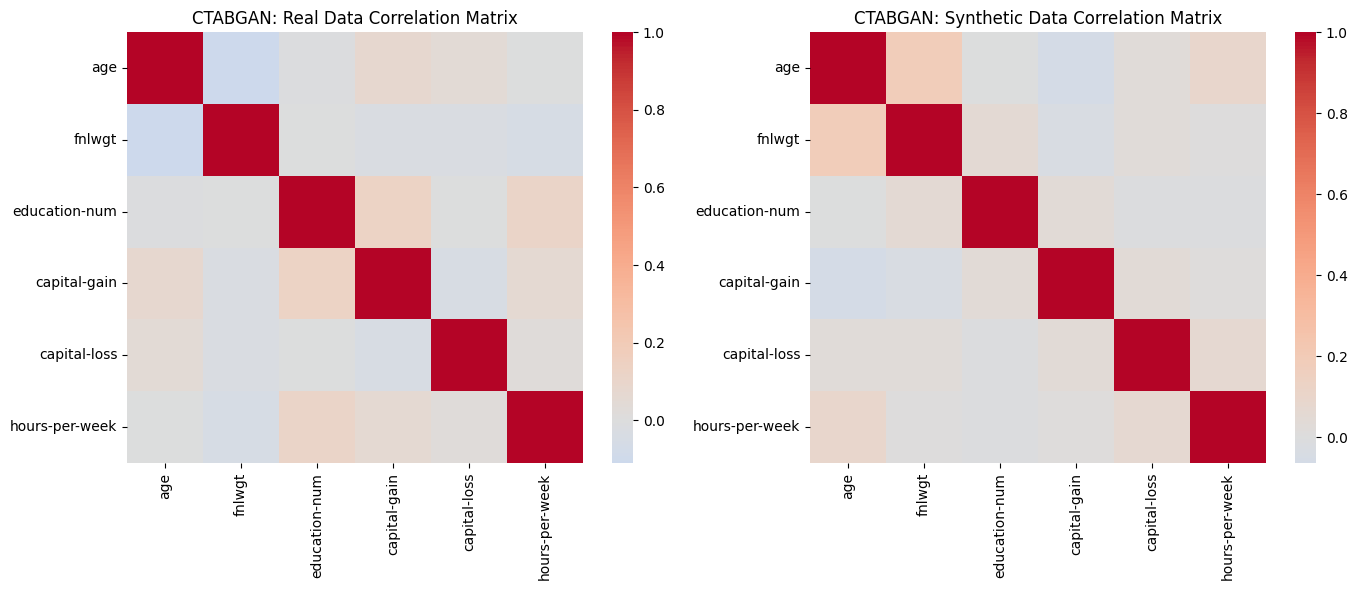

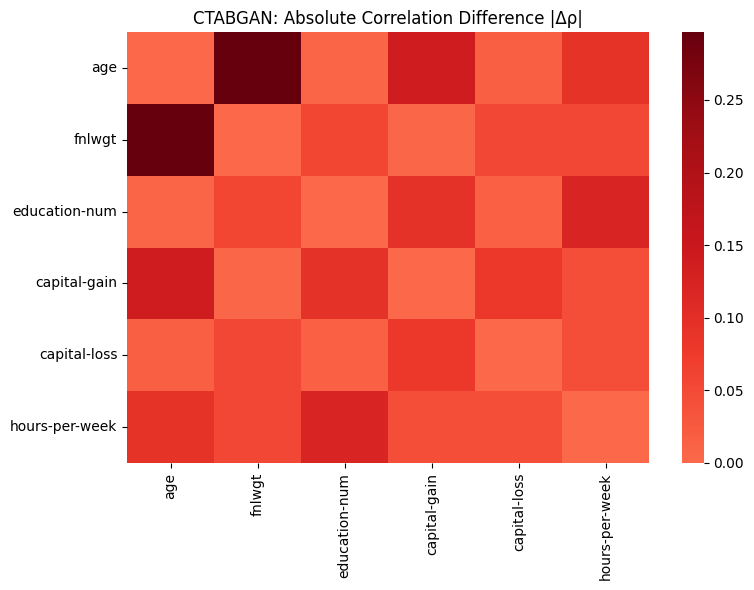

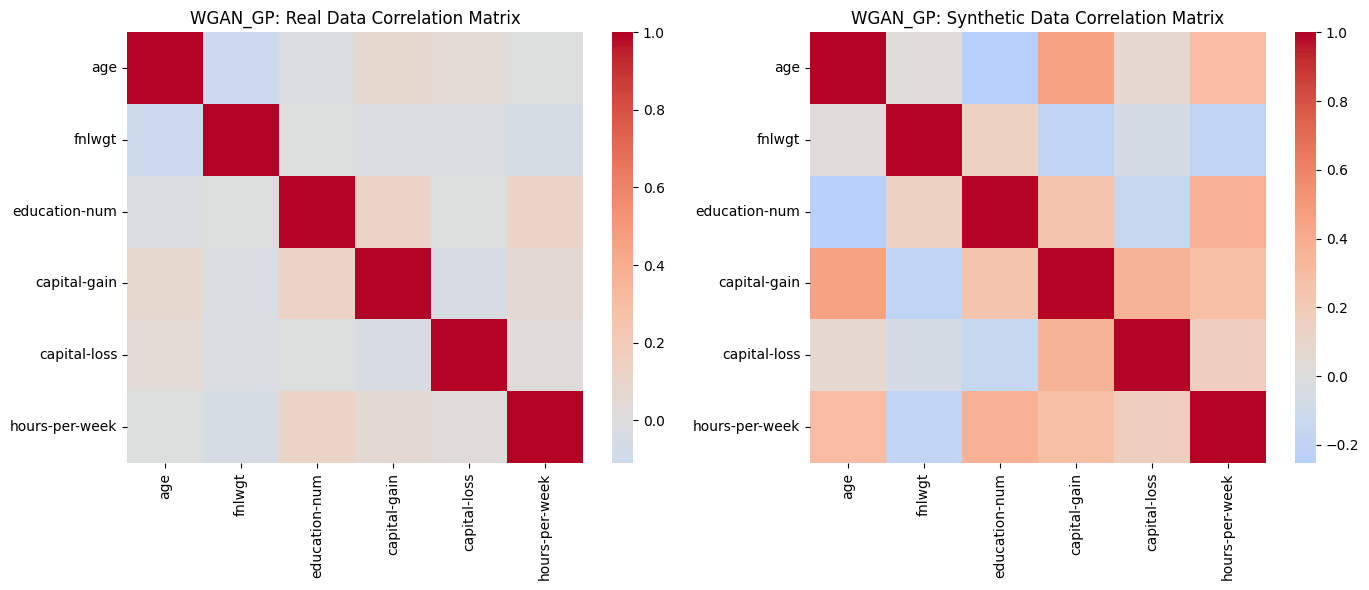

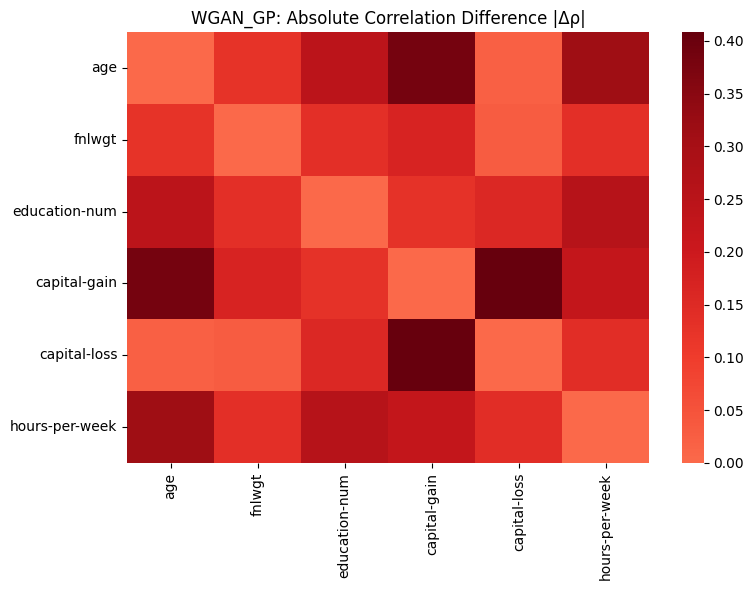

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTABGAN", "WGAN_GP"]

target_col = "Group" if "Group" in data.columns else "Group"

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

# remove target if it ended up in numeric columns
if target_col in num_cols:
    num_cols.remove(target_col)

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    # align columns safely
    common_cols = real_df.columns.intersection(synth_df.columns)
    synth_df = synth_df[common_cols]

    # keep only numeric columns for correlation
    synth_num_cols = [c for c in num_cols if c in synth_df.columns]
    synth_corr = synth_df[synth_num_cols].corr()

    # make sure both matrices use the same order
    common_num_cols = [c for c in num_cols if c in synth_corr.columns]
    real_corr_plot = real_corr.loc[common_num_cols, common_num_cols]
    synth_corr_plot = synth_corr.loc[common_num_cols, common_num_cols]

    # 1) Real vs Synthetic correlation matrices
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr_plot, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr_plot, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    # 2) Absolute correlation difference heatmap
    diff_corr = (real_corr_plot - synth_corr_plot).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()


CTABGAN - Global MMD (RBF): 0.077750


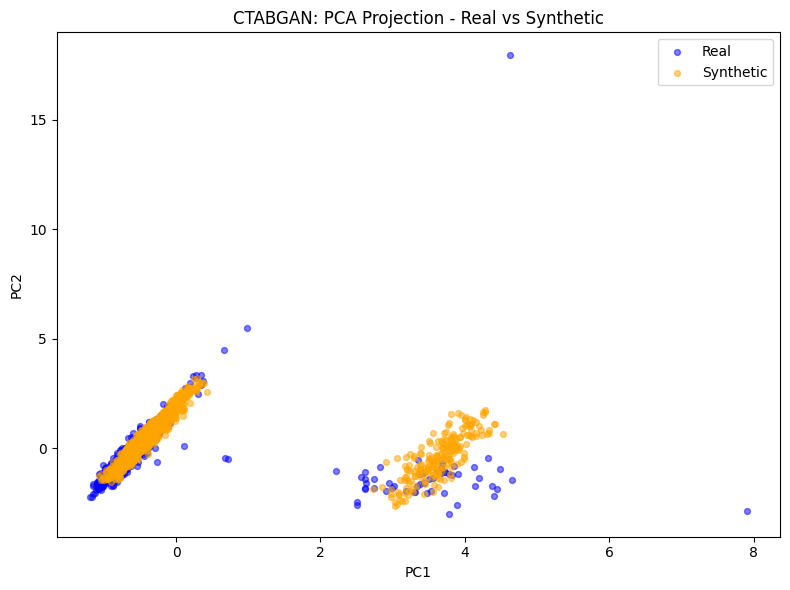

CTABGAN - Two-Sample Classifier Accuracy: 0.9733

WGAN_GP - Global MMD (RBF): 0.060505


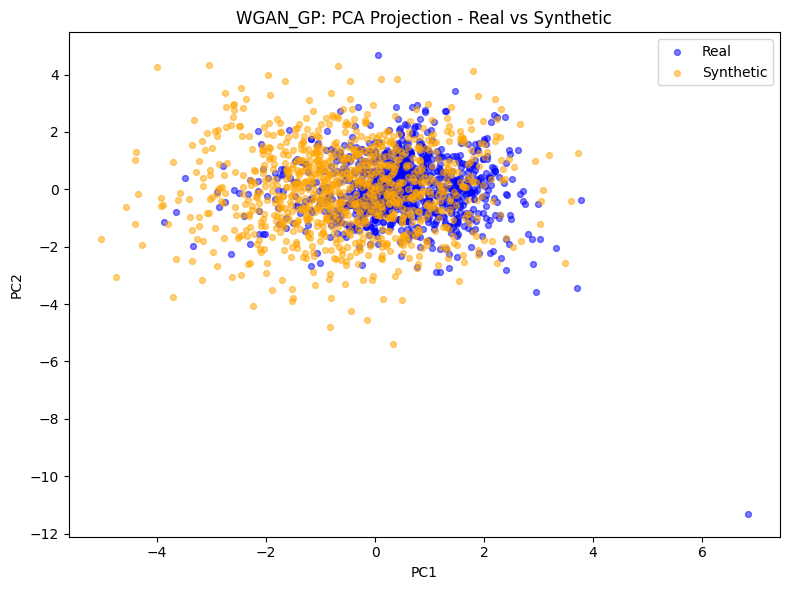

WGAN_GP - Two-Sample Classifier Accuracy: 1.0000

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,WGAN_GP,0.060505,1.000000
1,CTABGAN,0.077750,0.973333


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model_order = ["CTABGAN", "WGAN_GP"]

def mmd_rbf(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        dists = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
        med = np.median(dists[dists > 0])
        gamma = 1.0 / (2 * (med ** 2)) if med > 0 else 1.0
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)
    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

target_col = "Group" if "Group" in data.columns else "Group"
X_real_df = data.drop(columns=[target_col], errors="ignore")
X_real_df = X_real_df.select_dtypes(include=[np.number])

results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    synth_df = synth_df.drop(columns=[target_col], errors="ignore")
    synth_df = synth_df.select_dtypes(include=[np.number])

    common_cols = X_real_df.columns.intersection(synth_df.columns)
    X_real = X_real_df[common_cols].values
    X_synth = synth_df[common_cols].values

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": mmd_value,
        "C2ST_Accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)

# 4 Utility with 10 classifiers 

In [40]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    "LogReg": LogisticRegression(max_iter=5000, solver="liblinear", random_state=42),
    "SVM-RBF": SVC(kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "GradientBoost": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

def clean_income_labels(y):
    y = y.astype(str).str.strip()
    y = y.str.replace(".", "", regex=False)
    y = y.replace({
        "<=50K": 0,
        ">50K": 1
    })
    return y.astype(int)

def evaluate_models(train_df, test_df, label_col="income", models=models, test_size=0.2, seed=42):
    if label_col not in train_df.columns or label_col not in test_df.columns:
        raise KeyError(f"'{label_col}' not found in both train_df and test_df")

    num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
    if label_col in num_cols:
        num_cols.remove(label_col)

    X_train = train_df[num_cols].fillna(train_df[num_cols].median())
    X_test = test_df[num_cols].fillna(test_df[num_cols].median())

    y_train = clean_income_labels(train_df[label_col])
    y_test = clean_income_labels(test_df[label_col])

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=y_train
    )

    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=y_test
    )

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []
    for name, clf in models.items():
        try:
            clf.fit(X_train_s, y_train)
            y_pred = clf.predict(X_test_s)

            if hasattr(clf, "predict_proba"):
                y_prob = clf.predict_proba(X_test_s)[:, 1]
            elif hasattr(clf, "decision_function"):
                scores = clf.decision_function(X_test_s)
                y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
            else:
                y_prob = None

            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average="binary", zero_division=0)
            auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

            rows.append({"Model": name, "Accuracy": acc, "F1": f1, "AUC": auc})
        except Exception as e:
            print(f"Error with {name}: {str(e)[:80]}")
            rows.append({"Model": name, "Accuracy": np.nan, "F1": np.nan, "AUC": np.nan})

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False)

In [41]:
import pandas as pd

label_col = real_sample.columns[-1]  # Use absolute target column

# Only the models you actually trained
model_order = ["CTABGAN", "WGAN_GP"]

# First: evaluate on real data (TRTR)
trtr_results = evaluate_models(
    train_df=real_sample,
    test_df=real_sample,
    label="income",
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    # Evaluate: train on synthetic, test on real (TSTR)
    tstr_results = evaluate_models(
        train_df=synthetic_outputs[synth_name],
        test_df=real_sample,
        label="income",
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    # Compare with TRTR performance
    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    # AUC drop (loss of predictive power when training on synthetic)
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]

    # Optional drops if columns exist
    if "F1_TRTR" in comparison.columns and "F1_TSTR" in comparison.columns:
        comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]

    if "Accuracy_TRTR" in comparison.columns and "Accuracy_TSTR" in comparison.columns:
        comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]

    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("AUC_Drop", ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

# Combine all synthetic-model comparisons into one table
combined_comparison = pd.concat(all_comparisons, ignore_index=True)

# Summary: average AUC drop by synthetic model (lower is better)
summary = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
    .mean()
    .sort_values("AUC_Drop")
)

print("Average AUC drop by synthetic generator (lower is better):")
display(summary)


TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
5,RandomForest,0.815,0.506667,0.845448
7,GradientBoost,0.830,0.527778,0.830466
3,NaiveBayes,0.815,0.478873,0.828387
0,LogReg,0.820,0.513514,0.826953
9,MLP,0.805,0.493506,0.821075
8,AdaBoost,0.840,0.555556,0.803584
6,ExtraTrees,0.820,0.538462,0.801649
1,SVM-RBF,0.825,0.461538,0.782796
2,KNN,0.820,0.526316,0.776703
4,DecisionTree,0.790,0.522727,0.691039


CTABGAN - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,F1,AUC
0,LogReg,0.775,0.000000,0.745376
3,NaiveBayes,0.765,0.040816,0.690609
9,MLP,0.715,0.197183,0.634552
5,RandomForest,0.730,0.181818,0.620287
6,ExtraTrees,0.750,0.218750,0.615197
2,KNN,0.725,0.225352,0.579928
7,GradientBoost,0.715,0.313253,0.579140
8,AdaBoost,0.760,0.000000,0.576703
4,DecisionTree,0.665,0.279570,0.531541
1,SVM-RBF,0.780,0.043478,0.513405


CTABGAN - TRTR vs TSTR Comparison


...

,Model,Accuracy,F1,AUC
3,NaiveBayes,0.775,0.563107,0.807455
0,LogReg,0.755,0.514851,0.804731
7,GradientBoost,0.825,0.606742,0.794839
8,AdaBoost,0.795,0.559140,0.794337
6,ExtraTrees,0.825,0.578313,0.788674
1,SVM-RBF,0.780,0.531915,0.781075
5,RandomForest,0.820,0.590909,0.778710
9,MLP,0.700,0.500000,0.762007
2,KNN,0.785,0.537634,0.750394
4,DecisionTree,0.680,0.466667,0.659498


WGAN_GP - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop,F1_Drop,Accuracy_Drop,Synthetic_Model
0,RandomForest,0.815,0.506667,0.845448,0.820,0.590909,0.778710,0.066738,-0.084242,-0.005,WGAN_GP
4,MLP,0.805,0.493506,0.821075,0.700,0.500000,0.762007,0.059068,-0.006494,0.105,WGAN_GP
1,GradientBoost,0.830,0.527778,0.830466,0.825,0.606742,0.794839,0.035627,-0.078964,0.005,WGAN_GP
9,DecisionTree,0.790,0.522727,0.691039,0.680,0.466667,0.659498,0.031541,0.056061,0.110,WGAN_GP
8,KNN,0.820,0.526316,0.776703,0.785,0.537634,0.750394,0.026308,-0.011319,0.035,WGAN_GP
3,LogReg,0.820,0.513514,0.826953,0.755,0.514851,0.804731,0.022222,-0.001338,0.065,WGAN_GP
2,NaiveBayes,0.815,0.478873,0.828387,0.775,0.563107,0.807455,0.020932,-0.084234,0.040,WGAN_GP
6,ExtraTrees,0.820,0.538462,0.801649,0.825,0.578313,0.788674,0.012975,-0.039852,-0.005,WGAN_GP
5,AdaBoost,0.840,0.555556,0.803584,0.795,0.559140,0.794337,0.009247,-0.003584,0.045,WGAN_GP
7,SVM-RBF,0.825,0.461538,0.782796,0.780,0.531915,0.781075,0.001720,-0.070376,0.045,WGAN_GP


Average AUC drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_Drop
1,WGAN_GP,0.028638
0,CTABGAN,0.192136



CTABGAN - TSTR


,Model,Accuracy,F1,AUC
0,LogReg,0.775,0.000000,0.745376
3,NaiveBayes,0.765,0.040816,0.690609
9,MLP,0.715,0.197183,0.634552
5,RandomForest,0.730,0.181818,0.620287
6,ExtraTrees,0.750,0.218750,0.615197
2,KNN,0.725,0.225352,0.579928
7,GradientBoost,0.715,0.313253,0.579140
8,AdaBoost,0.760,0.000000,0.576703
4,DecisionTree,0.665,0.279570,0.531541
1,SVM-RBF,0.780,0.043478,0.513405


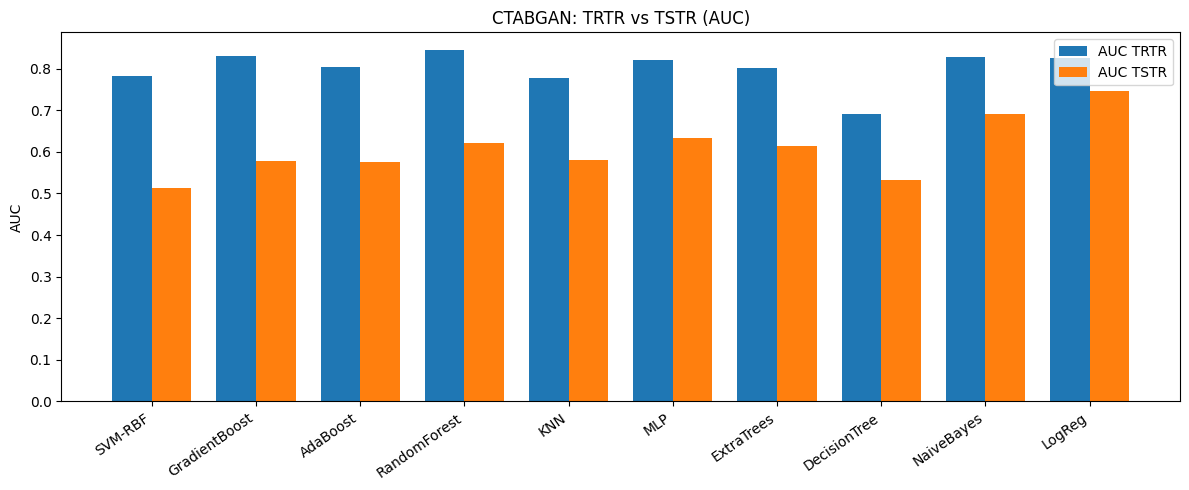

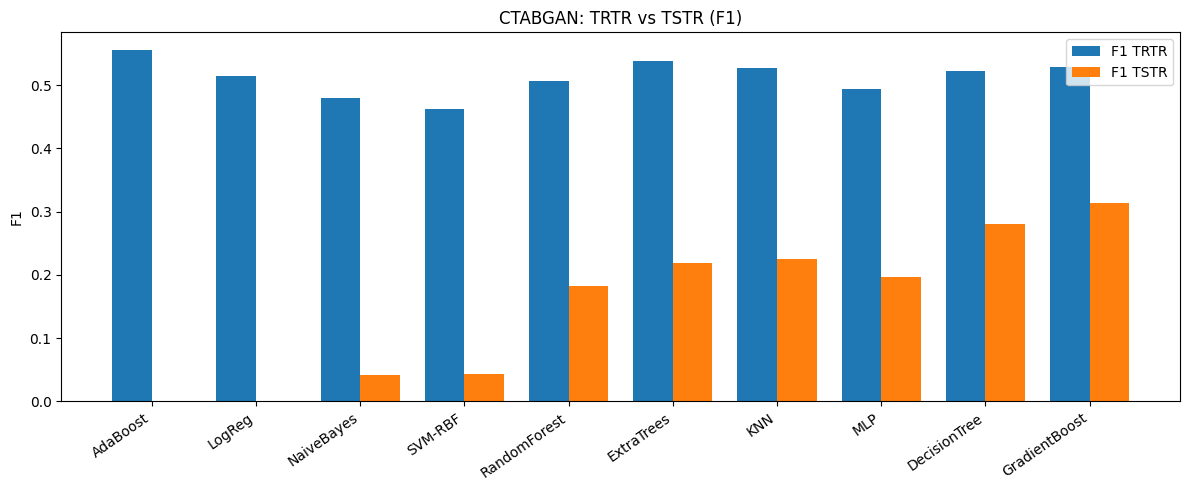

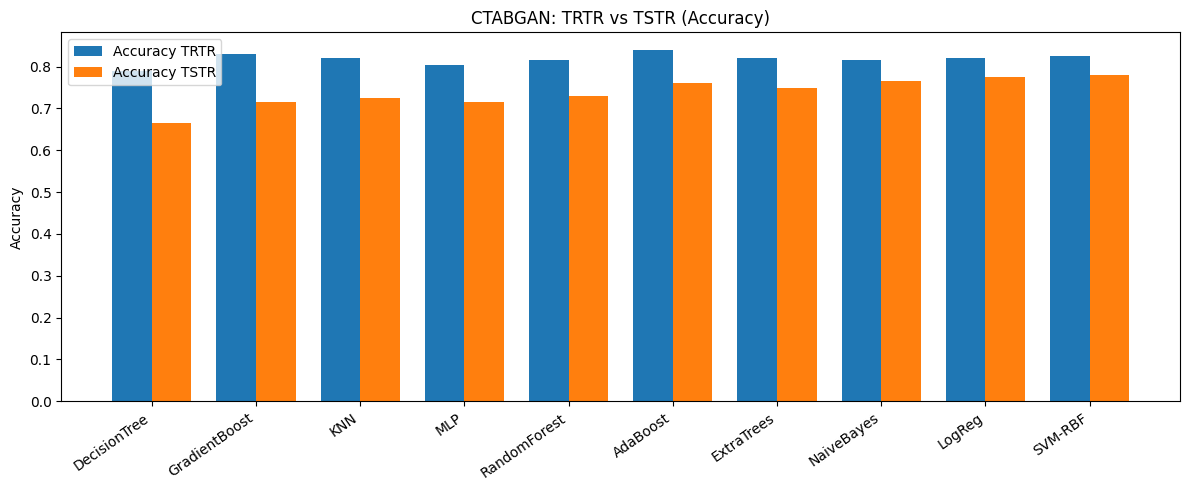

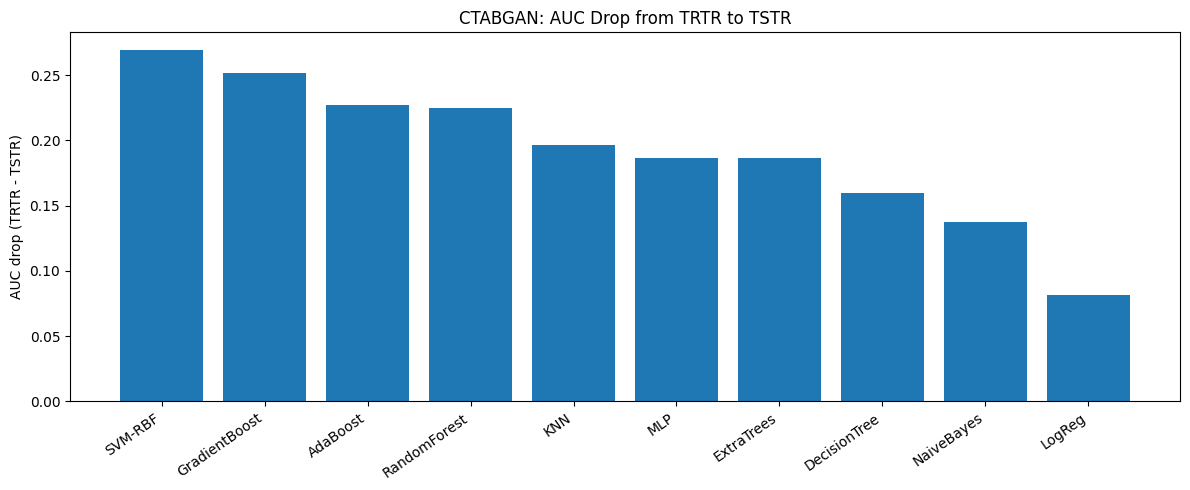


WGAN_GP - TSTR


,Model,Accuracy,F1,AUC
3,NaiveBayes,0.775,0.563107,0.807455
0,LogReg,0.755,0.514851,0.804731
7,GradientBoost,0.825,0.606742,0.794839
8,AdaBoost,0.795,0.559140,0.794337
6,ExtraTrees,0.825,0.578313,0.788674
1,SVM-RBF,0.780,0.531915,0.781075
5,RandomForest,0.820,0.590909,0.778710
9,MLP,0.700,0.500000,0.762007
2,KNN,0.785,0.537634,0.750394
4,DecisionTree,0.680,0.466667,0.659498


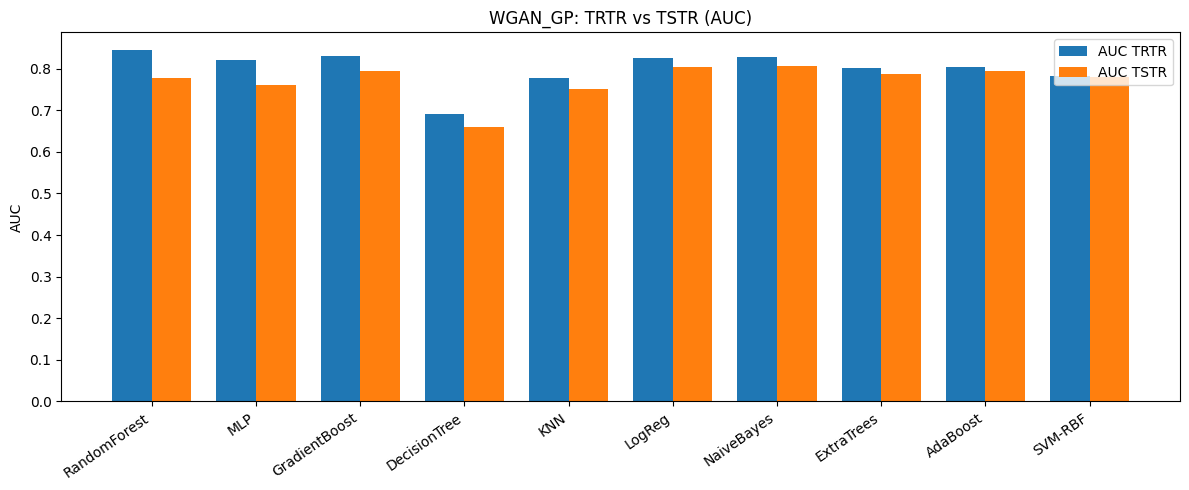

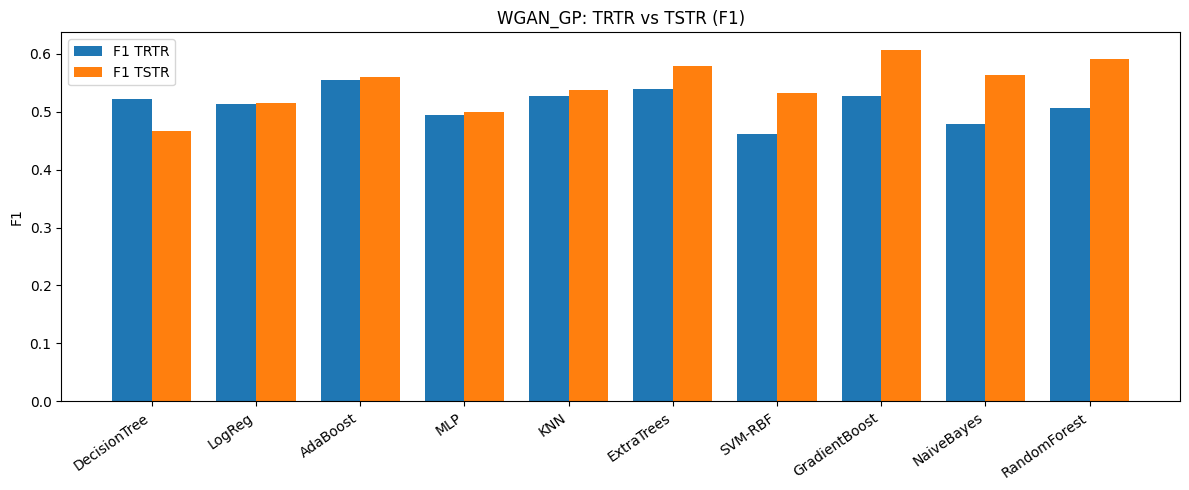

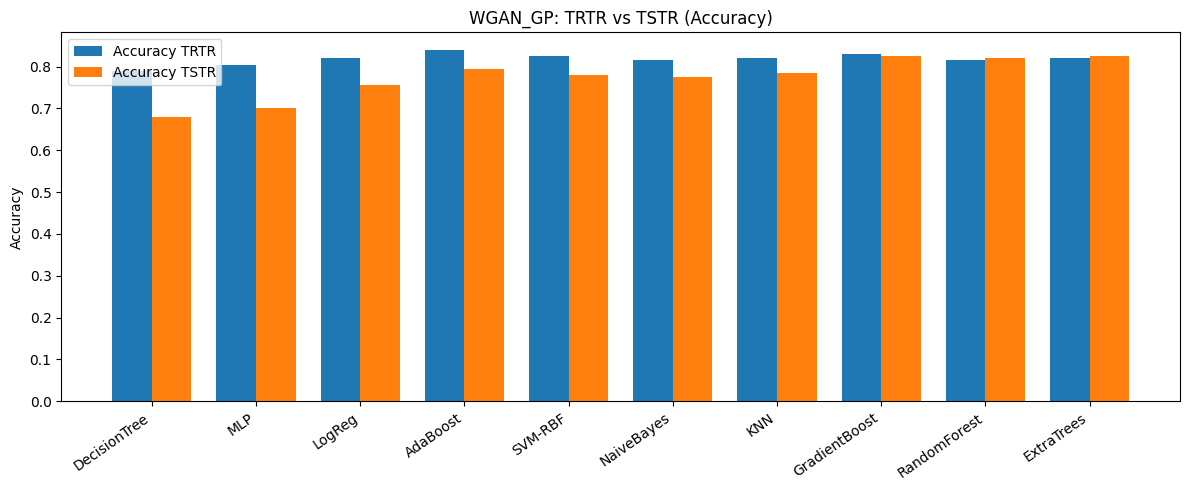

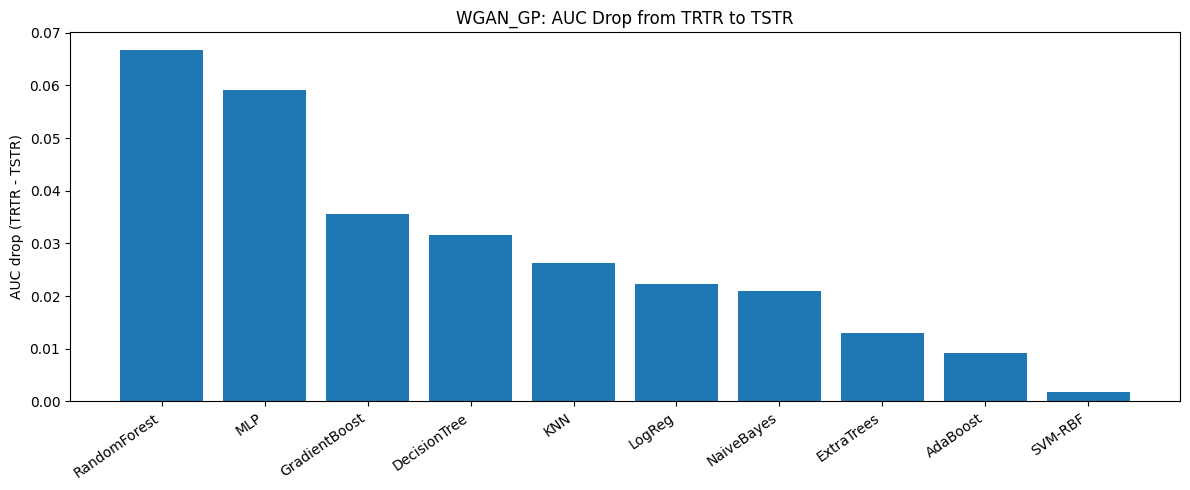


Average AUC drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_Drop
1,WGAN_GP,0.028638
0,CTABGAN,0.192136


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="AUC"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )
    df["Drop"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Drop", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_auc_drop(comparison_df, synth_name):
    if "AUC_Drop" not in comparison_df.columns:
        return

    df = comparison_df.sort_values("AUC_Drop", ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df["AUC_Drop"])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel("AUC drop (TRTR - TSTR)")
    plt.title(f"{synth_name}: AUC Drop from TRTR to TSTR")
    plt.tight_layout()
    plt.show()

# Fixed for Adult dataset
label_col = "income"
model_order = ["CTABGAN", "WGAN_GP"]

# Clean and prepare real data
data_eval = real_sample.copy()
data_eval[label_col] = clean_income_labels(data_eval[label_col])  # From previous cell

# Clean synthetic data
synthetic_eval = {}
for name in model_order:
    df = synthetic_outputs[name].copy()
    if label_col in df.columns:
        df[label_col] = clean_income_labels(df[label_col])
    synthetic_eval[name] = df

# TRTR baseline
trtr_results = evaluate_models(
    train_df=data_eval,
    test_df=data_eval,
    label="income",
    models=models
)

all_comp = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_eval[synth_name],
        test_df=data_eval,
        label="income",
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    # Plot comparisons
    for metric in ["AUC", "F1", "Accuracy"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    plot_auc_drop(comparison, synth_name)

# Summary table
combined_comparison = pd.concat(all_comp, ignore_index=True)
summary_auc = (
    combined_comparison.groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
    .mean()
    .sort_values("AUC_Drop")
)

print("\nAverage AUC drop by synthetic generator (lower is better):")
display(summary_auc)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    metrics = ["Accuracy", "F1", "AUC"]
    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per classifier (Accuracy, F1, AUC)\n"
        f"Shaded area = generalization gap (TRTR - TSTR)",
        fontsize=14
    )
    plt.show()

# Fixed for Adult dataset + clean labels
label_col = "income"
generators = ["CTABGAN", "WGAN_GP"]

# Clean and prepare real data (using clean_income_labels from previous cell)
data_eval = real_sample.copy()
data_eval[label_col] = clean_income_labels(data_eval[label_col])

# TRTR baseline
trtr_results = evaluate_models(
    train_df=data_eval,
    test_df=data_eval,
    label="income",
    models=models
)

for gen in generators:
    synth_eval = synthetic_outputs[gen].copy()
    if label_col in synth_eval.columns:
        synth_eval[label_col] = clean_income_labels(synth_eval[label_col])

    tstr_results = evaluate_models(
        train_df=synth_eval,
        test_df=data_eval,
        label="income",
        models=models
    )

    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )


# 5 Statistical similarity tests 

Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTABGAN,142.051511,9.678911,16.021075
1,WGAN_GP,49.179406,14.833392,17.185482


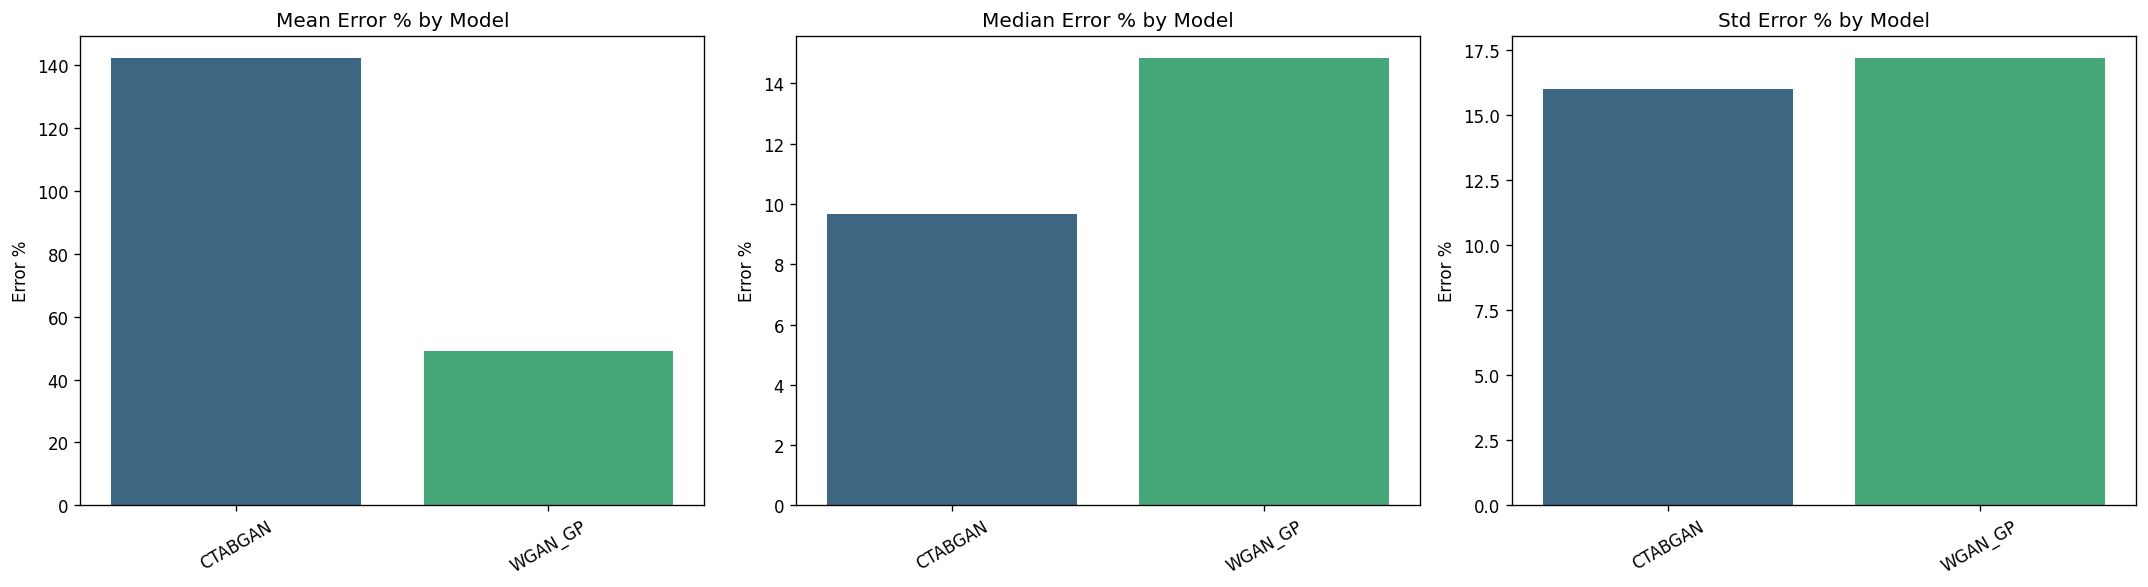

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTABGAN", "WGAN_GP"]

target_col = "income"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    
    # Align columns and handle NaN
    synth_df = synth_df[num_cols].fillna(synth_df[num_cols].median())
    real_df_aligned = real_df[num_cols].fillna(real_df[num_cols].median())
    
    real_means = real_df_aligned.mean()
    synth_means = synth_df.mean()

    real_stds = real_df_aligned.std(ddof=1)
    synth_stds = synth_df.std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()

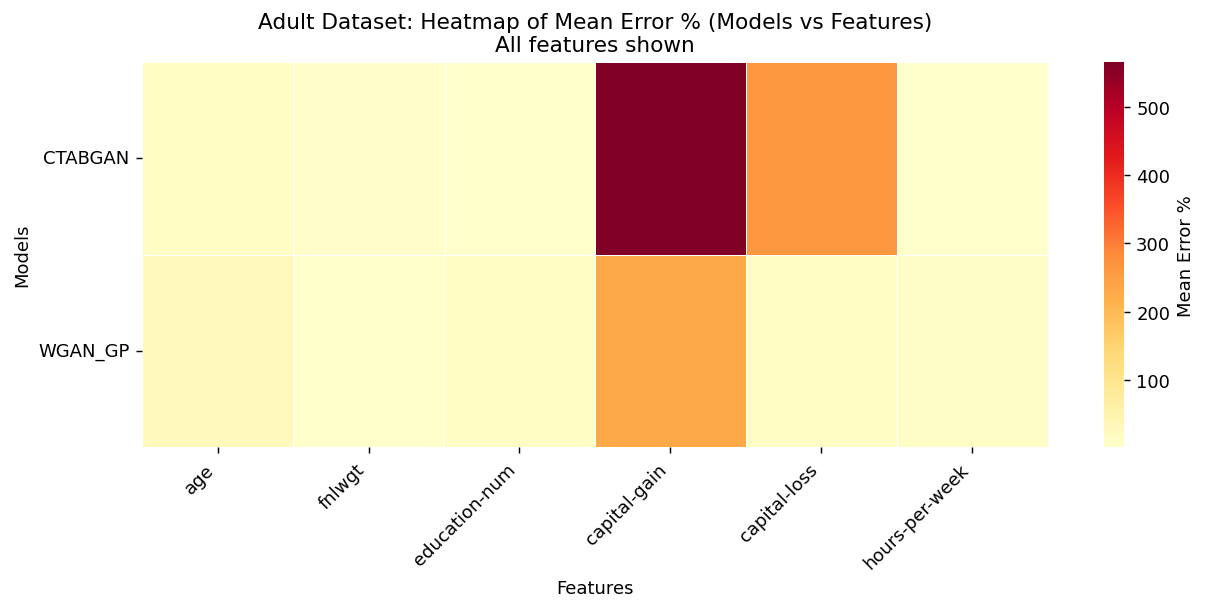

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTABGAN", "WGAN_GP"]

# Create heatmap from feature_error_by_model (previous cell)
heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
    if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Adult Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

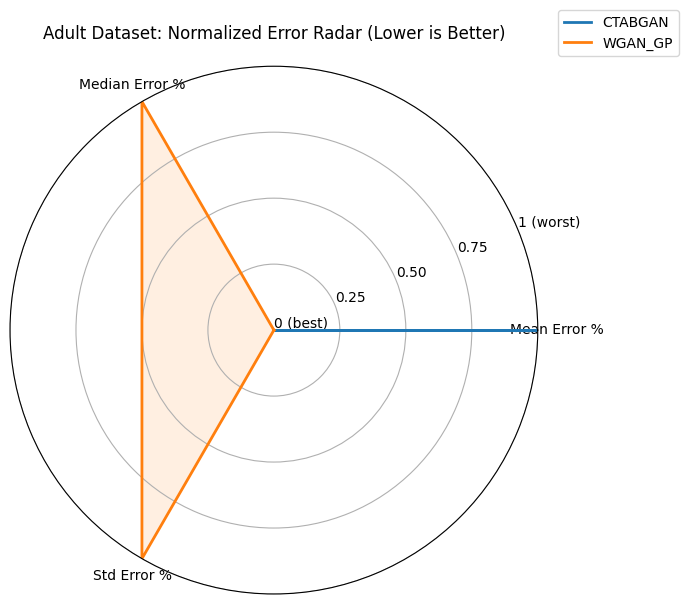

,Model,Mean Error %,Median Error %,Std Error %
0,CTABGAN,1.0,0.0,0.0
1,WGAN_GP,0.0,1.0,1.0


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Requires summary_df with columns:
# ["Model", "Mean Error %", "Median Error %", "Std Error %"]
# from previous statistical moments cell

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
radar_df = summary_df[["Model"] + metrics].copy()

# Min-max normalize each metric across models (0 = best / lowest error, 1 = worst / highest error)
norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Adult Dataset: Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))
plt.tight_layout()
plt.show()

display(norm_df)

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,WGAN_GP,61.166667,39.0,210
1,CTABGAN,76.833333,50.0,195


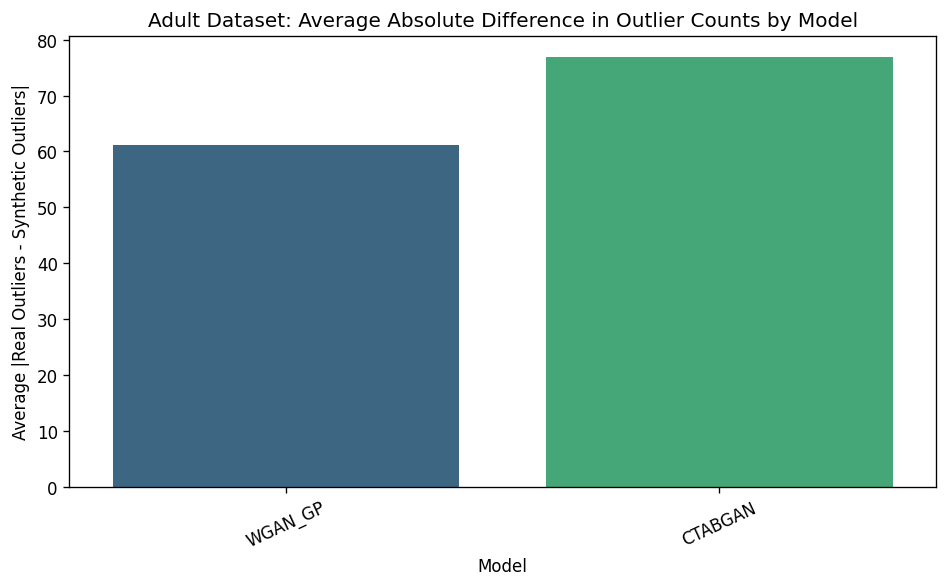

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTABGAN", "WGAN_GP"]

target_col = "income"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

# Handle NaN before outlier detection
real_df_clean = real_df[num_cols].fillna(real_df[num_cols].median())
real_outliers = {c: outlier_count_iqr(real_df_clean[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_outputs[model].copy()
    
    # Clean synthetic data and align columns
    synth_df_clean = synth_df[num_cols].fillna(synth_df[num_cols].median())
    synth_num_cols = [c for c in num_cols if c in synth_df_clean.columns]
    
    synth_outliers = {c: outlier_count_iqr(synth_df_clean[c]) for c in synth_num_cols}

    feat_df = pd.DataFrame({
        "Feature": synth_num_cols,
        "Real_Outliers": [real_outliers[c] for c in synth_num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in synth_num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].mean(),
        "Median_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].median(),
        "Max_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].max()
    })

outlier_summary_df = pd.DataFrame(rows).sort_values("Avg_Abs_Diff_Outlier_Count").reset_index(drop=True)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")
plt.title("Adult Dataset: Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 6. Cosine Similarity with Hungraian Mapping

In [ ]:
from numpy.linalg import norm
import numpy as np
import pandas as pd

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def cosine_similarity_matrix(real_df, synth_df, num_cols=None, target_col=None):
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col is None:
        target_col = "income"
    if target_col in num_cols:
        num_cols.remove(target_col)

    # Handle NaN before normalization
    R_clean = real_df[num_cols].fillna(real_df[num_cols].median()).to_numpy(dtype=float)
    S_clean = synth_df[num_cols].fillna(synth_df[num_cols].median()).to_numpy(dtype=float)
    
    return normalize_rows(R_clean) @ normalize_rows(S_clean).T

# Fixed for Adult dataset pipeline
synthetic_data = synthetic_outputs

cosine_results = {}
cosine_dfs = {}

model_order = ["WGAN_GP", "CTABGAN"]
target_col = "income"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = normalize_rows(real_df[num_cols].fillna(real_df[num_cols].median()).to_numpy(dtype=float))

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"Warning: {model_name} not found. Available: {list(synthetic_data.keys())}")
        continue

    synth_df = synthetic_data[model_name].copy()
    
    # Clean and align columns
    synth_clean = synth_df[num_cols].fillna(synth_df[num_cols].median())
    print(f"Building cosine similarity for {model_name}...")

    synth_matrix = normalize_rows(synth_clean.to_numpy(dtype=float))
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(f"{model_name} cosine sample:\n", cosine_df.round(3), "\n")

display(pd.DataFrame(cosine_results).T)


In [58]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    target_col = "Group" if "Group" in real_data.columns else "Group"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_data[num_cols].to_numpy(dtype=float)
    S = synthetic_data[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns]
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")


WGAN_GP - Top 10 Real -> Synthetic Matchings
01. R10 -> S448   cosine similarity = 1.0000
02. R479 -> S90   cosine similarity = 1.0000
03. R897 -> S503   cosine similarity = 1.0000
04. R403 -> S138   cosine similarity = 1.0000
05. R718 -> S415   cosine similarity = 1.0000
06. R564 -> S782   cosine similarity = 1.0000
07. R730 -> S552   cosine similarity = 1.0000
08. R852 -> S336   cosine similarity = 1.0000
09. R857 -> S939   cosine similarity = 1.0000
10. R996 -> S939   cosine similarity = 1.0000

CTABGAN - Top 10 Real -> Synthetic Matchings
01. R144 -> S619   cosine similarity = 1.0000
02. R191 -> S9   cosine similarity = 1.0000
03. R449 -> S695   cosine similarity = 1.0000
04. R975 -> S773   cosine similarity = 1.0000
05. R288 -> S619   cosine similarity = 1.0000
06. R970 -> S773   cosine similarity = 1.0000
07. R258 -> S773   cosine similarity = 1.0000
08. R104 -> S773   cosine similarity = 1.0000
09. R248 -> S619   cosine similarity = 1.0000
10. R600 -> S416   cosine similarity =

In [ ]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    target_col = "Group" if "Group" in real_df.columns else "Group"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = data.copy()

synthetic_data = synthetic_outputs

results = {}

for name, synth_df in synthetic_data.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features)")
    print(f"==============================")

    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common].copy()

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")

summary_df = pd.DataFrame(
    [{"Model": name, "Avg_Hungarian_Cosine": info["avg_similarity"]} for name, info in results.items()]
).sort_values("Avg_Hungarian_Cosine", ascending=False)

display(summary_df)


In [61]:
import pandas as pd
import numpy as np

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

target_col = "Group" if "Group" in real_df.columns else "Group"
if target_col in feature_cols:
    feature_cols.remove(target_col)

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found. Expected `synthetic_outputs`, `synthetic_data`, or `synthetic_tables`.")

model_order = ["WGAN_GP", "CTABGAN"]  # ← FIXED: Match your results keys
output_file = "Adult_Hungarian_Matchings_All_Models.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results:
            print(f"Skipping {model_name}: no Hungarian results found")
            continue
        if model_name not in synth_source:
            print(f"Skipping {model_name}: no synthetic data found")
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]
        sims = results[model_name]["similarities"]

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            "cosine_similarity": sims
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns]
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        sheet_name = model_name[:31]
        side_by_side.to_excel(writer, sheet_name=sheet_name, index=False)

        combined_rows.append(side_by_side)
        summary_rows.append({
            "Model": model_name,
            "Num_Matches": len(sims),
            "Avg_Cosine_Similarity": float(np.mean(sims)),
            "Median_Cosine_Similarity": float(np.median(sims)),
            "Min_Cosine_Similarity": float(np.min(sims)),
            "Max_Cosine_Similarity": float(np.max(sims)),
        })

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows).sort_values("Avg_Cosine_Similarity", ascending=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        display(summary_df)  # ← FIXED: Moved inside with block

print(f"Saved: {output_file}")

,Model,Num_Matches,Avg_Cosine_Similarity,Median_Cosine_Similarity,Min_Cosine_Similarity,Max_Cosine_Similarity
1,CTABGAN,1000,0.998985,0.999750,0.961660,1.0
0,WGAN_GP,1000,0.806117,0.999875,-0.999979,1.0


Saved: Adult_Hungarian_Matchings_All_Models.xlsx


# 7. Mahalanobis distance with Hungrain Mapping  

In [62]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

target_col = "Group" if "Group" in data.columns else "Group"

data_numeric = data.select_dtypes(include=[np.number]).dropna().copy()
if target_col in data_numeric.columns:
    data_numeric = data_numeric.drop(columns=[target_col])

real_matrix = data_numeric.to_numpy(dtype=float)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real data.
Mean shape: (6,), Inv_cov shape: (6, 6)


In [63]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis

# First compute real distribution statistics (you need these first)
real_numeric = data[num_cols].to_numpy(dtype=float)
mu_real = np.mean(real_numeric, axis=0)
cov_real = np.cov(real_numeric, rowvar=False)
inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))  # Stabilize

# Smart synthetic source detection (same as your Excel cell)
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found.")

target_col = "Group" if "Group" in data.columns else "Group"
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

mahalanobis_results = {}
available_models = []

for name in ["WGAN_GP", "CTABGAN"]:
    if name in synth_source:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)
        
        # Compute Mahalanobis distances
        dists = [mahalanobis(x, mu_real, inv_cov_real) for x in synth_numeric]
        dists = np.array(dists)
        
        mahalanobis_results[name] = {
            "mean": float(np.mean(dists)),
            "median": float(np.median(dists)),
            "std": float(np.std(dists)),
            "min": float(np.min(dists)),
            "max": float(np.max(dists)),
            "distances": dists,
        }
        available_models.append(name)
        print(f"✓ {name}: mean Mahalanobis = {np.mean(dists):.3f}")
    else:
        print(f"✗ {name} not found in synthetic source. Available: {list(synth_source.keys())}")

# Create summary only for available models
if mahalanobis_results:
    summary = pd.DataFrame({
        name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
        for name, r in mahalanobis_results.items()
    }, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T
    
    summary.index.name = "Model"
    summary = summary.sort_values("mean_dist")
    
    print("Mahalanobis distance to real distribution (lower is better):")
    display(summary)
else:
    print("No valid synthetic data found for Mahalanobis analysis.")

✓ WGAN_GP: mean Mahalanobis = 2.747
✓ CTABGAN: mean Mahalanobis = 2.911
Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
WGAN_GP,2.747301,2.620685,0.935377,0.766523,6.782780
CTABGAN,2.911239,2.725452,1.152947,0.307821,6.427151


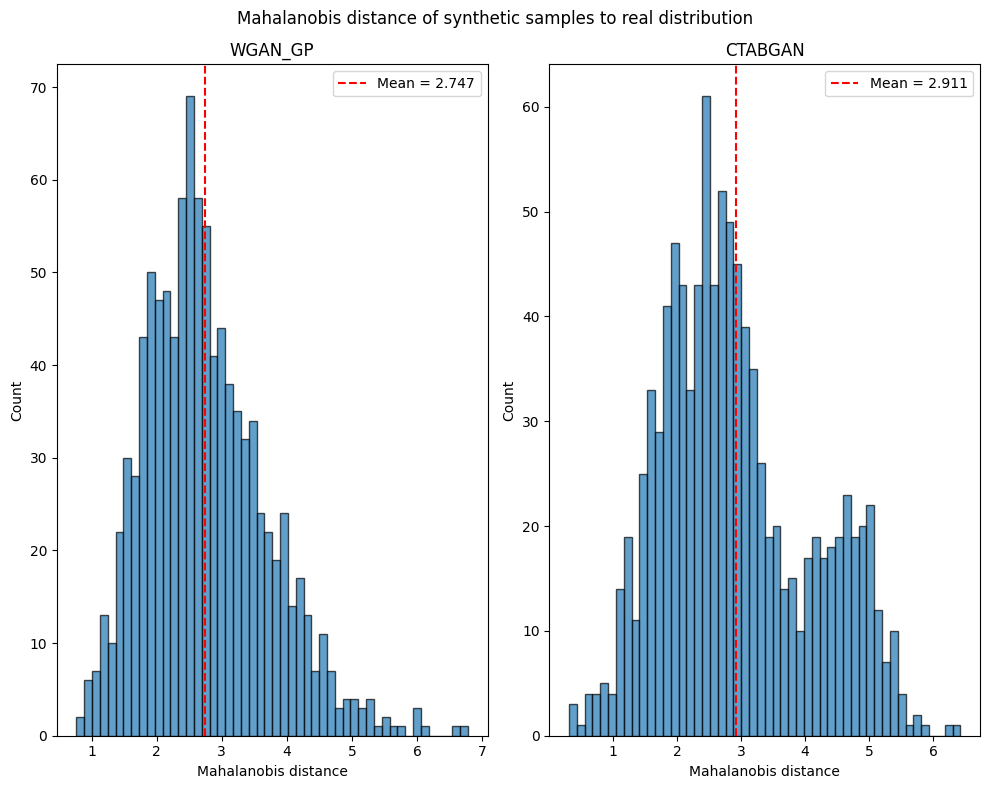

In [64]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mahalanobis distance of synthetic samples to real distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_cancer_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

# Fixed for Adult dataset pipeline
target_col = "income"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

# Clean data and compute covariance inverse
real_matrix = real_df[num_cols].fillna(real_df[num_cols].median()).to_numpy(dtype=float)
cov_real = np.cov(real_matrix, rowvar=False)
inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

hungarian_results = {}
available_models = []

# Map your synthetic outputs (from generation pipeline)
synthetic_data = synthetic_outputs

model_order = ["WGAN_GP", "CTABGAN"]

for name in model_order:
    if name in synthetic_data:
        synth_df = synthetic_data[name][num_cols].copy()
        synth_numeric = synth_df.fillna(synth_df.median()).to_numpy(dtype=float)
        
        n_matches = min(real_matrix.shape[0], synth_numeric.shape[0])
        print(f"✓ Processing {name} ({n_matches} matches from {synth_numeric.shape[0]} synth samples)")
        
        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        row_ind, col_ind = linear_sum_assignment(D)
        matched_distances = D[row_ind, col_ind]

        hungarian_results[name] = {
            "total_distance": float(matched_distances.sum()),
            "mean_distance_per_match": float(matched_distances.mean()),
            "median_distance_per_match": float(np.median(matched_distances)),
            "std_distance_per_match": float(np.std(matched_distances)),
            "max_distance_per_match": float(matched_distances.max()),
            "matched_distances": matched_distances,
            "row_ind": row_ind,
            "col_ind": col_ind,
            "n_matches": n_matches
        }
        available_models.append(name)
    else:
        print(f"✗ {name} not in synthetic data. Available: {list(synthetic_data.keys())}")

# Summary table
if hungarian_results:
    hungarian_summary = pd.DataFrame(
        {
            name: [
                r["mean_distance_per_match"],
                r["median_distance_per_match"],
                r["std_distance_per_match"],
                r["max_distance_per_match"],
                r["n_matches"]
            ]
            for name, r in hungarian_results.items()
        },
        index=[
            "mean_distance_per_match",
            "median_distance_per_match", 
            "std_distance_per_match",
            "max_distance_per_match",
            "n_matches"
        ],
    ).T

    hungarian_summary.index.name = "Model"
    hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

    print("Adult Dataset: Hungarian matching using Mahalanobis distance (lower is better):")
    display(hungarian_summary)
else:
    print("No valid models found for Mahalanobis Hungarian matching.")


In [66]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found. Expected `synthetic_outputs`, `synthetic_data`, or `synthetic_tables`.")

# Compute numeric features (exclude target)
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
target_col = "Group" if "Group" in data.columns else "Group"
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = data[num_cols].to_numpy(dtype=float)

# Compute real covariance inverse (if not already done)
if 'inv_cov_real' not in globals():
    cov_real = np.cov(real_matrix, rowvar=False)
    inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

hungarian_results = {}
available_models = []

# Your GAN models
for name in ["WGAN_GP", "CTABGAN"]:
    if name in synth_source:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)
        
        # REMOVED size check - Hungarian handles rectangular matrices automatically
        n_real, n_synth = real_matrix.shape[0], synth_numeric.shape[0]
        n_matches = min(n_real, n_synth)
        print(f"✓ Processing {name}: {n_real} real vs {n_synth} synth → {n_matches} matches")
        
        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        row_ind, col_ind = linear_sum_assignment(D)
        matched_distances = D[row_ind, col_ind]

        hungarian_results[name] = {
            "total_distance": float(matched_distances.sum()),
            "mean_distance_per_match": float(matched_distances.mean()),
            "median_distance_per_match": float(np.median(matched_distances)),
            "std_distance_per_match": float(np.std(matched_distances)),
            "max_distance_per_match": float(matched_distances.max()),
            "matched_distances": matched_distances,
            "row_ind": row_ind,
            "col_ind": col_ind,
            "n_real": n_real,
            "n_synth": n_synth,
            "n_matches": n_matches
        }
        available_models.append(name)
    else:
        print(f"✗ {name} not in synthetic source. Available: {list(synth_source.keys())}")

# Summary table (only for successful models)
if hungarian_results:
    hungarian_summary = pd.DataFrame(
        {
            name: [
                r["mean_distance_per_match"],
                r["median_distance_per_match"],
                r["std_distance_per_match"],
                r["max_distance_per_match"],
                r["n_matches"]
            ]
            for name, r in hungarian_results.items()
        },
        index=[
            "mean_distance_per_match",
            "median_distance_per_match",
            "std_distance_per_match",
            "max_distance_per_match",
            "n_matches"
        ],
    ).T

    hungarian_summary.index.name = "Model"
    hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")
    
    print("Hungarian matching using Mahalanobis distance (lower is better):")
    display(hungarian_summary)
else:
    print("No valid models found for Mahalanobis Hungarian matching.")

✓ Processing WGAN_GP: 1000 real vs 1000 synth → 1000 matches
✓ Processing CTABGAN: 1000 real vs 1000 synth → 1000 matches
Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match,n_matches
Model,,,,,
WGAN_GP,1.872853,1.720587,1.099480,22.674445,1000.0
CTABGAN,1.900369,1.392402,1.586735,21.703330,1000.0


In [67]:
import numpy as np
import pandas as pd

def greedy_one_to_one_matching(D):
    n_rows, n_cols = D.shape
    n = min(n_rows, n_cols)

    used_rows = set()
    used_cols = set()
    pairs = []

    for _ in range(n):
        best_val = np.inf
        best_i, best_j = -1, -1

        for i in range(n_rows):
            if i in used_rows:
                continue
            for j in range(n_cols):
                if j in used_cols:
                    continue
                if D[i, j] < best_val:
                    best_val = D[i, j]
                    best_i, best_j = i, j

        if best_i < 0:
            break

        used_rows.add(best_i)
        used_cols.add(best_j)
        pairs.append((best_i, best_j, best_val))

    distances = np.array([p[2] for p in pairs], dtype=float)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

# Smart synthetic source detection (same as previous cells)
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found.")

# Use same numeric columns as previous Mahalanobis cell
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
target_col = "Group" if "Group" in data.columns else "Group"
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = data[num_cols].to_numpy(dtype=float)

greedy_results = {}
comparison_rows = []

# Your GAN models
for name in ["WGAN_GP", "CTABGAN"]:
    if name in synth_source and name in hungarian_results:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)
        
        print(f"✓ Processing {name}: {real_matrix.shape[0]} real vs {synth_numeric.shape[0]} synth")
        
        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        total_g, mean_g, _ = greedy_one_to_one_matching(D)

        greedy_results[name] = {
            "total_distance": total_g,
            "mean_distance": mean_g
        }

        # Compare with Hungarian results
        h_total = hungarian_results[name]["total_distance"]
        h_mean = hungarian_results[name]["mean_distance_per_match"]

        comparison_rows.append({
            "Model": name,
            "Greedy total": total_g,
            "Hungarian total": h_total,
            "Greedy mean": mean_g,
            "Hungarian mean": h_mean,
            "Total diff (Greedy - Hungarian)": total_g - h_total,
            "Mean diff (Greedy - Hungarian)": mean_g - h_mean,
        })
        print(f"  Greedy mean: {mean_g:.4f} vs Hungarian: {h_mean:.4f} (diff: {mean_g-h_mean:.4f})")
    else:
        print(f"✗ Skipping {name} (missing data or Hungarian results)")

# Greedy summary
if greedy_results:
    greedy_summary = pd.DataFrame({
        name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
        for name in greedy_results
    }, index=["total_distance", "mean_distance"]).T
    greedy_summary.index.name = "Model"
    
    print("Greedy one-to-one matching (Mahalanobis distance):")
    display(greedy_summary)

    print("\nComparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):")
    comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
    display(comparison_df)
else:
    print("No valid models for greedy matching.")

✓ Processing WGAN_GP: 1000 real vs 1000 synth
  Greedy mean: 2.0928 vs Hungarian: 1.8729 (diff: 0.2199)
✓ Processing CTABGAN: 1000 real vs 1000 synth
  Greedy mean: 1.9781 vs Hungarian: 1.9004 (diff: 0.0777)
Greedy one-to-one matching (Mahalanobis distance):


,total_distance,mean_distance
Model,,
WGAN_GP,2092.762887,2.092763
CTABGAN,1978.102211,1.978102



Comparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):


,Greedy total,Hungarian total,Greedy mean,Hungarian mean,Total diff (Greedy - Hungarian),Mean diff (Greedy - Hungarian)
Model,,,,,,
WGAN_GP,2092.762887,1872.853483,2.092763,1.872853,219.909404,0.219909
CTABGAN,1978.102211,1900.368704,1.978102,1.900369,77.733507,0.077734


In [ ]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

# Fixed for Adult dataset pipeline
real_df = real_sample.copy()
target_col = "income"
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

X_real = real_df[feature_cols].fillna(real_df[feature_cols].median()).to_numpy(dtype=float)

# Covariance with regularization (pinv is better than inv for stability)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

# Your GAN models from generation pipeline
model_order = ["WGAN_GP", "CTABGAN"]
hungarian_results = {}

synthetic_data = synthetic_outputs

for model_name in model_order:
    if model_name in synthetic_data:
        synth_df = synthetic_data[model_name][feature_cols].copy()
        X_synth = synth_df.fillna(synth_df.median()).to_numpy(dtype=float)
        
        print(f"✓ Processing {model_name}: {X_real.shape[0]} real vs {X_synth.shape[0]} synth")
        
        D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

        # Hungarian handles rectangular matrices automatically
        row_ind, col_ind = linear_sum_assignment(D)
        dists = D[row_ind, col_ind]
        
        hungarian_results[model_name] = {
            "row_ind": row_ind, 
            "col_ind": col_ind, 
            "dists": dists
        }

        # Top matches
        order = np.argsort(dists)
        top_k = min(20, len(order))
        print(f"\n{model_name} - Top {top_k} Hungarian matchings (lowest Mahalanobis distance):")
        for rank, k in enumerate(order[:top_k], 1):
            print(f"{rank:02d}. R{row_ind[k] + 1} -> S{col_ind[k] + 1}   distance = {dists[k]:.4f}")
    else:
        print(f"✗ {model_name} not in synthetic data. Available: {list(synthetic_data.keys())}")

# Summary stats
if hungarian_results:
    summary_stats = pd.DataFrame({
        model_name: {
            "mean_dist": np.mean(hungarian_results[model_name]["dists"]),
            "median_dist": np.median(hungarian_results[model_name]["dists"]),
            "min_dist": np.min(hungarian_results[model_name]["dists"])
        }
        for model_name in hungarian_results
    }).T.sort_values("mean_dist")
    print("\nAdult Dataset: Summary Mahalanobis distances (lower is better):")
    display(summary_stats)


In [79]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import pandas as pd

# Direct synthetic source (your pipeline)
synth_source = synthetic_outputs

# Fixed for Adult dataset pipeline
real_df = real_sample.copy()
target_col = "income"
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

# Clean data before matrix operations
X_real = real_df[feature_cols].fillna(real_df[feature_cols].median()).to_numpy(dtype=float)

# Covariance with regularization (pinv for numerical stability)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

# Your GAN models from generation pipeline
model_order = ["CTABGAN", "WGAN_GP"]

for model_name in model_order:
    if model_name in synth_source:
        synth_df = synth_source[model_name][feature_cols].copy()
        X_synth = synth_df.fillna(synth_df.median()).to_numpy(dtype=float)
        
        print(f"\n{'='*60}")
        print(f"{model_name}: {X_real.shape[0]} real vs {X_synth.shape[0]} synth")
        print(f"{'='*60}")
        
        D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

        # Hungarian matching (handles rectangular matrices automatically)
        row_ind, col_ind = linear_sum_assignment(D)
        dists = D[row_ind, col_ind]
        
        r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

        print(f"{model_name} - Hungarian mappings for R1 to R20:")
        for r in range(20):
            if r in r_to_match:
                s, dist = r_to_match[r]
                print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
            else:
                print(f"R{r+1} -> No match found")

        # Summary stats for this model
        print(f"  Summary: mean={np.mean(dists):.4f}, median={np.median(dists):.4f}, min={np.min(dists):.4f}")
    else:
        print(f"✗ {model_name} not in synthetic_outputs. Available: {list(synth_source.keys())}")


CTABGAN: 1000 real vs 1000 synth
CTABGAN - Hungarian mappings for R1 to R20:
R1 -> S553   distance = 1.2760
R2 -> S206   distance = 1.8225
R3 -> S715   distance = 1.1420
R4 -> S380   distance = 4.3860
R5 -> S612   distance = 0.3296
R6 -> S534   distance = 0.1103
R7 -> S39   distance = 1.1789
R8 -> S569   distance = 0.9367
R9 -> S452   distance = 1.8563
R10 -> S106   distance = 2.0308
R11 -> S463   distance = 0.3599
R12 -> S526   distance = 2.5653
R13 -> S718   distance = 1.7900
R14 -> S416   distance = 0.1972
R15 -> S777   distance = 4.3206
R16 -> S93   distance = 0.8605
R17 -> S130   distance = 1.7257
R18 -> S405   distance = 0.5814
R19 -> S706   distance = 1.3590
R20 -> S812   distance = 1.1232
  Summary: mean=1.9004, median=1.3924, min=0.0103

WGAN_GP: 1000 real vs 1000 synth
WGAN_GP - Hungarian mappings for R1 to R20:
R1 -> S434   distance = 3.0692
R2 -> S786   distance = 1.7535
R3 -> S865   distance = 2.4472
R4 -> S371   distance = 1.7760
R5 -> S794   distance = 0.8906
R6 -> S626


Processing CTABGAN: 1000 real vs 1000 synth


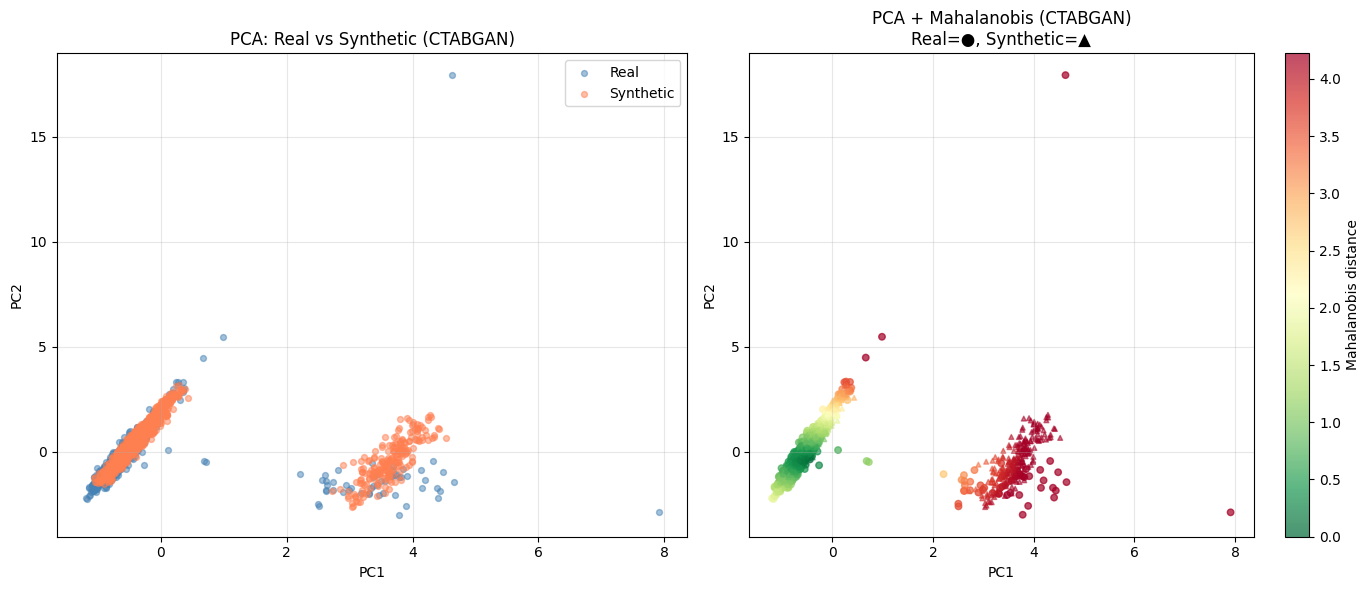

  Real mean MD: 0.8845, Synth mean MD: 1.7454, Delta: +0.8609

Processing WGAN_GP: 1000 real vs 1000 synth


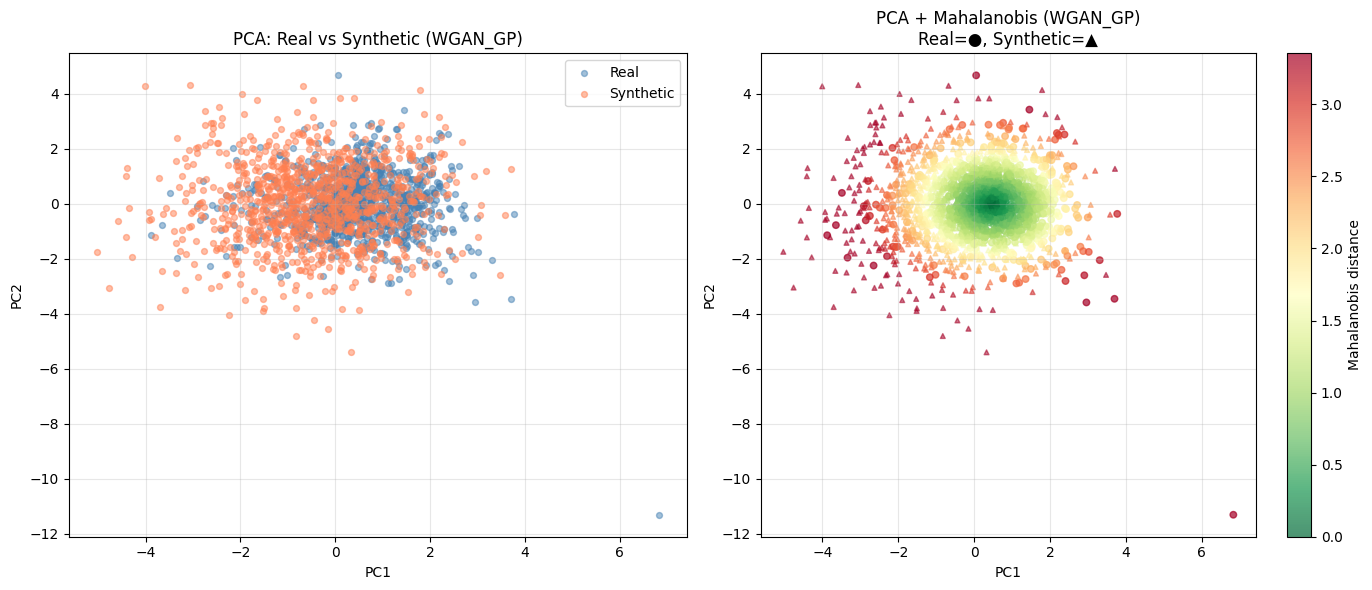

  Real mean MD: 1.1764, Synth mean MD: 1.8469, Delta: +0.6705

Adult Dataset: Summary PCA 2D Mahalanobis distances (lower Synth_Mean_MD_2D = better):


,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
0,CTABGAN,0.884515,1.745427,0.860912
1,WGAN_GP,1.176433,1.846910,0.670477


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

# Direct pipeline reference
synth_source = synthetic_outputs

model_order = ["CTABGAN", "WGAN_GP"]
real_df = real_sample.copy()
target_col = "income"
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

# Scale and clean real data
X_r = real_df[feature_cols].fillna(real_df[feature_cols].median()).to_numpy(dtype=float)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synth_source:
        print(f"✗ {model_name} not in synthetic_outputs, skipping.")
        continue

    synth_df = synth_source[model_name][feature_cols].copy()
    X_s = synth_df.fillna(synth_df.median()).to_numpy(dtype=float)
    X_s_s = scaler.transform(X_s)

    print(f"\n{'='*60}")
    print(f"Processing {model_name}: {X_r.shape[0]} real vs {X_s.shape[0]} synth")
    print(f"{'='*60}")

    # PCA on combined data
    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    # Mahalanobis in PCA space (real distribution reference)
    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = inv(cov_z + 10 * reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    # Plot 1: PCA scatter
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: Mahalanobis distance color-coded
    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Stats
    print(f"  Real mean MD: {d_r.mean():.4f}, Synth mean MD: {d_s.mean():.4f}, Delta: {d_s.mean()-d_r.mean():+.4f}")
    
    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

# Summary table
if rows:
    summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
    print("\nAdult Dataset: Summary PCA 2D Mahalanobis distances (lower Synth_Mean_MD_2D = better):")
    display(summary_df)
else:
    print("No valid models found.")

In [81]:
import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Adult_Hungarian_Mahalanobis.xlsx"
):
    # Fixed model names to match your pipeline
    model_order = ["CTABGAN", "WGAN_GP"]  # Match hungarian_results keys

    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                print(f"Skipping {model_name}: missing data or results")
                continue

            synth_df = synthetic_data[model_name][num_cols].copy()
            synth_df = synth_df.fillna(synth_df.median())  # Clean NaN

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            # Flexible distance key detection
            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                print(f"No distance array found for {model_name}, skipping")
                continue

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                # Limit to first 10 numeric features for Excel practicality
                for c in num_cols[:10]:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = model_name[:31]  # Excel sheet name limit
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"✓ Exported {len(matched_df)} matches for {model_name}")

            summary_rows.append({
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="Summary", index=False)
            print("\nSummary table:")
            display(summary_df)

    print(f"\n✅ Excel file created: {filename}")

# ---- Run with your actual pipeline variables ----
synth_source = synthetic_outputs  # Your generation results
real_df = real_sample.copy()     # Your Adult dataset
target_col = "income"
num_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

print(f"Adult Dataset: {len(real_df)} samples, {len(num_cols)} numeric features")
print(f"Target column: {target_col}")
print(f"Available models: {list(synth_source.keys())}")
print(f"Hungarian results keys: {list(hungarian_results.keys()) if 'hungarian_results' in globals() else 'Not found'}")

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synth_source,
    hungarian_results=hungarian_results,  # From your Hungarian matching cell
    num_cols=num_cols,
    filename="Adult_Hungarian_Mahalanobis.xlsx"
)

Adult Dataset: 1000 samples, 6 numeric features
Target column: income
Available models: ['Real', 'CTABGAN', 'WGAN_GP']
Hungarian results keys: ['WGAN_GP', 'CTABGAN']
✓ Exported 1000 matches for CTABGAN


Exception ignored in: <function ZipFile.__del__ at 0x000001428A3577E0>
Traceback (most recent call last):
  File "c:\Users\Gopi.Battineni\AppData\Local\anaconda3\envs\UGE\Lib\zipfile\__init__.py", line 1988, in __del__
    self.close()
  File "c:\Users\Gopi.Battineni\AppData\Local\anaconda3\envs\UGE\Lib\zipfile\__init__.py", line 2005, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


✓ Exported 1000 matches for WGAN_GP

Summary table:


,Model,Num_Matches,Mean_Distance,Median_Distance,Std_Distance,Min_Distance,Max_Distance
1,WGAN_GP,1000,1.872853,1.720587,1.099480,0.291333,22.674445
0,CTABGAN,1000,1.900369,1.392402,1.586735,0.010335,21.703330



✅ Excel file created: Adult_Hungarian_Mahalanobis.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [83]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample(model, X, y, eps=1e-15):
    proba = model.predict_proba(X)
    n = len(y)
    y_idx = y.astype(int).clip(0, proba.shape[1] - 1)
    p_true = proba[np.arange(n), y_idx] + eps
    return -np.log(p_true)

def privacy_metrics_mia(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample(model, X_train_s, y_train)
    loss_test = model_loss_per_sample(model, X_test_s, y_test)

    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

# Fixed for Adult dataset pipeline
target_col = "income"
feature_cols = [c for c in real_sample.select_dtypes(include=[np.number]).columns if c != target_col]
model_order = ["CTABGAN", "WGAN_GP"]

# Clean and encode real data once
real_df = real_sample.copy()
real_df[feature_cols] = real_df[feature_cols].fillna(real_df[feature_cols].median())
le = LabelEncoder()
y_real_encoded = le.fit_transform(clean_income_labels(real_df[target_col]))  # Use clean labels

results = []

for model_name in model_order:
    if model_name not in synthetic_outputs:
        print(f"✗ {model_name} not in synthetic_outputs")
        continue
    
    print(f"\n{'='*50}")
    print(f"MIA for {model_name}")
    print(f"{'='*50}")
    
    synth_df = synthetic_outputs[model_name].copy()
    synth_df[feature_cols] = synth_df[feature_cols].fillna(synth_df[feature_cols].median())
    
    # Encode synthetic labels using same encoder
    y_synth_encoded = le.transform(clean_income_labels(synth_df[target_col]))

    X_train = real_df[feature_cols].to_numpy(dtype=float)
    y_train = y_real_encoded

    X_test = synth_df[feature_cols].to_numpy(dtype=float)
    y_test = y_synth_encoded

    model = LogisticRegression(max_iter=1000, random_state=42)
    metrics = privacy_metrics_mia(model, X_train, y_train, X_test, y_test)
    
    metrics["Model"] = model_name
    results.append(metrics)
    
    print(f"  AUC: {metrics['AUC']:.4f}")
    print(f"  Advantage: {metrics['Advantage']:.4f}")
    print(f"  TPR@FPR=0.01: {metrics['TPR_at_FPR_001']:.4f}")

# Summary
if results:
    summary_df = pd.DataFrame(results).set_index("Model")
    print("\nMIA Results (LOWER AUC = BETTER privacy protection):")
    display(summary_df.sort_values("AUC"))
else:
    print("No valid models found.")


MIA for CTABGAN
  AUC: 0.7320
  Advantage: 0.3760
  TPR@FPR=0.01: 0.0390

MIA for WGAN_GP
  AUC: 0.4092
  Advantage: 0.0380
  TPR@FPR=0.01: 0.0030

MIA Results (LOWER AUC = BETTER privacy protection):


,AUC,Advantage,TPR_at_FPR_001
Model,,,
WGAN_GP,0.409170,0.038,0.003
CTABGAN,0.732016,0.376,0.039


In [84]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

# Fixed for Adult dataset pipeline
feature_cols = [c for c in real_sample.select_dtypes(include=[np.number]).columns 
                if c != "income"]
X_train = real_sample[feature_cols].fillna(real_sample[feature_cols].median()).to_numpy(dtype=float)

model_order = ["CTABGAN", "WGAN_GP"]
rows = []

print("Mahalanobis MIA - Real vs Synthetic (Adult Dataset)")
print("="*70)

for model_name in model_order:
    if model_name not in synthetic_outputs:
        print(f"✗ {model_name} not in synthetic_outputs, skipping")
        continue
    
    print(f"\n✓ Processing {model_name}...")
    X_test = synthetic_outputs[model_name][feature_cols].fillna(
        synthetic_outputs[model_name][feature_cols].median()
    ).to_numpy(dtype=float)
    
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

# Results table
if rows:
    comparison_df = pd.DataFrame(rows)[
        ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
    ].sort_values("AUC", ascending=False).reset_index(drop=True)
    
    print("\nMIA (Mahalanobis Distance) Results:")
    print("• HIGHER AUC = WORSE privacy (easier to distinguish real vs synthetic)")
    print("• Train/Test MD: How far synthetic samples are from real distribution")
    print("• LOWER AUC = BETTER privacy protection")
    display(comparison_df)
    
    # Privacy ranking
    print("\nPrivacy Ranking (LOWER AUC = BETTER privacy):")
    ranked = comparison_df.sort_values("AUC").reset_index(drop=True)
    for idx, row in ranked.iterrows():
        rank_emoji = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉"
        print(f"{rank_emoji} {row['Model']}: AUC={row['AUC']:.3f} | Test_MD={row['Test_MD_Mean']:.3f}")
else:
    print("No valid models found.")

Mahalanobis MIA - Real vs Synthetic (Adult Dataset)

✓ Processing CTABGAN...

✓ Processing WGAN_GP...

MIA (Mahalanobis Distance) Results:
• HIGHER AUC = WORSE privacy (easier to distinguish real vs synthetic)
• Train/Test MD: How far synthetic samples are from real distribution
• LOWER AUC = BETTER privacy protection


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,CTABGAN,0.727949,0.377,0.050,2.085999,2.911238
1,WGAN_GP,0.721710,0.373,0.131,2.085999,2.747300



Privacy Ranking (LOWER AUC = BETTER privacy):
🥇 WGAN_GP: AUC=0.722 | Test_MD=2.747
🥈 CTABGAN: AUC=0.728 | Test_MD=2.911
